# Indian Job Market 2025 — Exploratory Data Analysis

## Objective

This project explores the Indian job market using job posting data to understand:

- The most frequently posted job roles
- Companies with the highest number of job postings
- Geographic distribution of job opportunities
- Salary disclosure and salary distribution
- Experience requirements
- Skills frequently mentioned in job postings
- Relationship between experience and salary
- Salary differences across job roles and locations
- Work-mode patterns such as remote and hybrid opportunities

In [1]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)

# Plot settings
sns.set_theme(style="whitegrid")

In [2]:
df = pd.read_excel(
    r"C:\Users\riaka\Downloads\indian job market\indian-job-market-dataset-2025.xlsx"
)

df.head()

,title,jobId,currency,jobUploaded,companyName,tagsAndSkills,experience,salary,location,companyId,ReviewsCount,AggregateRating,jobDescription,minimumSalary,maximumSalary,minimumExperience,maximumExperience
0,Sr. HR Recruiter (NON IT),270925008041,INR,6 Days Ago,Orion,"Communication,Manpower,Staffing,Convincing Power,Hiring,Recruitment,SR,Communication skills",2-4 Yrs,2-4 Lacs PA,Kolkata(Chinar Park),645563,NaN,NaN,Preferred candidate profile . .,200000.0,400000.0,2.0,4.0
1,Fire And Safety Officer,270925007584,INR,6 Days Ago,"Apollo Hospitals International Limited, Ahmedabad","Safety Officer Activities,Fire Protection,Fire Safety,Fire Engineering,Fire Prevention,Safety Ma...",6-11 Yrs,3-5 Lacs PA,"Gandhinagar, Ahmedabad",14072,5162.0,4.0,"Ensure active Fire Protection System,such as Fire Hydrant system,Fire extinguishers,Fire Alarm s...",300000.0,500000.0,6.0,11.0
2,Opening For Performance Marketing - Chennai,270925007492,INR,6 Days Ago,TVS Credit Services Ltd,"Performance Marketing,User Acquisition,growth marketing,Paid Marketing,Acquisition,Performance,U...",12-18 Yrs,Not disclosed,Chennai,1324750,2892.0,4.2,MBA Marketing (preferred Tier II or III B- School). <br><br>Experience <br><br> 12+ years exp in...,0.0,0.0,12.0,18.0
3,Medical Billing Executive,270925007443,INR,6 Days Ago,GNR Global Services,"Fluent English,Spoken English,Good English Communication,Medical,Medical billing,Billing,Fluent,...",0-3 Yrs,"70,000-2 Lacs PA","Mohali, Chandigarh, Kharar, Zirakpur",123804403,NaN,NaN,Job Title-Medical Billing Executive\nLocation-Mohali\nSalary-20-22k ctc\n\nBenefits:\nCab facili...,70000.0,200000.0,0.0,3.0
4,Senior Group Product Manager - CNS Therapy,270925007430,INR,6 Days Ago,Cadila Pharmaceuticals,"Product Marketing,CNS,Product Management,Nephrology,Group Product Management,Brand Marketing,Neu...",5-10 Yrs,8-18 Lacs PA,Ahmedabad,14957,2134.0,3.4,Principal Tasks & Responsibilities : (Please write all the major jobs that the employee is requi...,800000.0,1800000.0,5.0,10.0


In [3]:
df.shape

(97929, 17)

In [4]:
df.head()

,title,jobId,currency,jobUploaded,companyName,tagsAndSkills,experience,salary,location,companyId,ReviewsCount,AggregateRating,jobDescription,minimumSalary,maximumSalary,minimumExperience,maximumExperience
0,Sr. HR Recruiter (NON IT),270925008041,INR,6 Days Ago,Orion,"Communication,Manpower,Staffing,Convincing Power,Hiring,Recruitment,SR,Communication skills",2-4 Yrs,2-4 Lacs PA,Kolkata(Chinar Park),645563,NaN,NaN,Preferred candidate profile . .,200000.0,400000.0,2.0,4.0
1,Fire And Safety Officer,270925007584,INR,6 Days Ago,"Apollo Hospitals International Limited, Ahmedabad","Safety Officer Activities,Fire Protection,Fire Safety,Fire Engineering,Fire Prevention,Safety Ma...",6-11 Yrs,3-5 Lacs PA,"Gandhinagar, Ahmedabad",14072,5162.0,4.0,"Ensure active Fire Protection System,such as Fire Hydrant system,Fire extinguishers,Fire Alarm s...",300000.0,500000.0,6.0,11.0
2,Opening For Performance Marketing - Chennai,270925007492,INR,6 Days Ago,TVS Credit Services Ltd,"Performance Marketing,User Acquisition,growth marketing,Paid Marketing,Acquisition,Performance,U...",12-18 Yrs,Not disclosed,Chennai,1324750,2892.0,4.2,MBA Marketing (preferred Tier II or III B- School). <br><br>Experience <br><br> 12+ years exp in...,0.0,0.0,12.0,18.0
3,Medical Billing Executive,270925007443,INR,6 Days Ago,GNR Global Services,"Fluent English,Spoken English,Good English Communication,Medical,Medical billing,Billing,Fluent,...",0-3 Yrs,"70,000-2 Lacs PA","Mohali, Chandigarh, Kharar, Zirakpur",123804403,NaN,NaN,Job Title-Medical Billing Executive\nLocation-Mohali\nSalary-20-22k ctc\n\nBenefits:\nCab facili...,70000.0,200000.0,0.0,3.0
4,Senior Group Product Manager - CNS Therapy,270925007430,INR,6 Days Ago,Cadila Pharmaceuticals,"Product Marketing,CNS,Product Management,Nephrology,Group Product Management,Brand Marketing,Neu...",5-10 Yrs,8-18 Lacs PA,Ahmedabad,14957,2134.0,3.4,Principal Tasks & Responsibilities : (Please write all the major jobs that the employee is requi...,800000.0,1800000.0,5.0,10.0


In [5]:
df.columns

Index(['title', 'jobId', 'currency', 'jobUploaded', 'companyName',
       'tagsAndSkills', 'experience', 'salary', 'location', 'companyId',
       'ReviewsCount', 'AggregateRating', 'jobDescription', 'minimumSalary',
       'maximumSalary', 'minimumExperience', 'maximumExperience'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97929 entries, 0 to 97928
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   title              97929 non-null  object 
 1   jobId              97929 non-null  int64  
 2   currency           97929 non-null  object 
 3   jobUploaded        97929 non-null  object 
 4   companyName        97925 non-null  object 
 5   tagsAndSkills      97358 non-null  object 
 6   experience         95824 non-null  object 
 7   salary             97929 non-null  object 
 8   location           97929 non-null  object 
 9   companyId          97929 non-null  int64  
 10  ReviewsCount       62677 non-null  float64
 11  AggregateRating    62677 non-null  float64
 12  jobDescription     97929 non-null  object 
 13  minimumSalary      97358 non-null  float64
 14  maximumSalary      97358 non-null  float64
 15  minimumExperience  97358 non-null  float64
 16  maximumExperience  973

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
jobId,97929.0,2.069854e+11,9.987860e+10,1.012500e+10,1.808250e+11,2.508250e+11,2.808250e+11,3.112240e+11
companyId,97929.0,2.784642e+07,4.979184e+07,3.000000e+00,2.339390e+05,2.892790e+06,6.398332e+06,1.251422e+08
ReviewsCount,62677.0,1.466259e+04,2.474451e+04,2.000000e+00,6.500000e+01,9.620000e+02,1.282600e+04,1.044490e+05
AggregateRating,62677.0,3.679048e+00,4.840962e-01,1.000000e+00,3.500000e+00,3.700000e+00,3.900000e+00,5.000000e+00
minimumSalary,97358.0,1.983092e+05,5.640765e+05,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+05,7.000000e+07
maximumSalary,97358.0,3.186096e+05,8.417336e+05,0.000000e+00,0.000000e+00,0.000000e+00,3.750000e+05,9.500000e+07
minimumExperience,97358.0,3.957744e+00,3.581196e+00,0.000000e+00,1.000000e+00,3.000000e+00,5.000000e+00,3.000000e+01
maximumExperience,97358.0,7.732647e+00,4.500161e+00,0.000000e+00,5.000000e+00,7.000000e+00,1.000000e+01,3.500000e+01


In [8]:
missing = pd.DataFrame({
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df) * 100).round(2)
})

missing = missing.sort_values('Missing_Count', ascending=False)

missing

,Missing_Count,Missing_Percentage
ReviewsCount,35252,36.00
AggregateRating,35252,36.00
experience,2105,2.15
maximumExperience,571,0.58
minimumExperience,571,0.58
maximumSalary,571,0.58
tagsAndSkills,571,0.58
minimumSalary,571,0.58
companyName,4,0.00
jobDescription,0,0.00


In [9]:
duplicate_rows = df.duplicated().sum()

print("Duplicate rows:", duplicate_rows)

Duplicate rows: 247


In [10]:
print("Total rows:", len(df))
print("Unique Job IDs:", df['jobId'].nunique())
print("Unique Company IDs:", df['companyId'].nunique())
print("Unique Company Names:", df['companyName'].nunique())

Total rows: 97929
Unique Job IDs: 97679
Unique Company IDs: 18328
Unique Company Names: 18668


In [11]:
df['currency'].value_counts()

currency
INR    97800
USD      129
Name: count, dtype: int64

In [12]:
# Find Job IDs that appear more than once
duplicate_job_ids = df[df['jobId'].duplicated(keep=False)].sort_values('jobId')

print("Rows with repeated Job IDs:", len(duplicate_job_ids))
print("Number of repeated Job IDs:", duplicate_job_ids['jobId'].nunique())

duplicate_job_ids.head(20)

Rows with repeated Job IDs: 500
Number of repeated Job IDs: 250


,title,jobId,currency,jobUploaded,companyName,tagsAndSkills,experience,salary,location,companyId,ReviewsCount,AggregateRating,jobDescription,minimumSalary,maximumSalary,minimumExperience,maximumExperience
18159,Senior Manager -Data Modeller,10425004190,INR,9 Days Ago,VOIS,"Teradata SQL,Data Architecture,Data Modeling,Data modeller,Data,Senior management,Teradata,SQL",10-18 Yrs,35-40 Lacs PA,Hybrid - Pune,647435,1132.0,3.9,"Preferred candidate profile :- Data Modeller,Data Architeture Architecture. Experance Ranges :- ...",3500000.0,4000000.0,10.0,18.0
18160,Senior Manager -Data Modeller,10425004190,INR,9 Days Ago,VOIS,"Teradata SQL,Data Architecture,Data Modeling,Data modeller,Data,Senior management,Teradata,SQL",10-18 Yrs,35-40 Lacs PA,Hybrid - Pune,647435,1132.0,3.9,"Preferred candidate profile :- Data Modeller,Data Architeture Architecture. Experance Ranges :- ...",3500000.0,4000000.0,10.0,18.0
3799,Manual Testing Engineer,11025010305,INR,2 Days Ago,KP Hr And Infra Services,"Database Testing,Web Based Application,Manual Testing,SQL Database,Mobile Application Testing,BF...",1-3 Yrs,5-8 Lacs PA,Pune(Senapati Bapat Road +1),3915296,NaN,NaN,"1.Manual testing\n2.Experience in Functional Testing of Web-Based application, Database Testing\...",500000.0,800000.0,1.0,3.0
3800,Manual Testing Engineer,11025010305,INR,2 Days Ago,KP Hr And Infra Services,"Database Testing,Web Based Application,Manual Testing,SQL Database,Mobile Application Testing,BF...",1-3 Yrs,5-8 Lacs PA,Pune(Senapati Bapat Road +1),3915296,NaN,NaN,"1.Manual testing\n2.Experience in Functional Testing of Web-Based application, Database Testing\...",500000.0,800000.0,1.0,3.0
15720,Senior Architect,11025010474,INR,2 Days Ago,One Desing,"Sketchup,Lumion,AutoCAD,REVIT,MS Office,English,Illustrator,Marathi",0-6 Yrs,1.8-4.2 Lacs PA,Nashik(Govind Nagar),125135755,NaN,NaN,<p>Responsibilities:</p><p>* Manage project timelines & budgets</p><p>* Ensure compliance with b...,180000.0,420000.0,0.0,6.0
15719,Senior Architect,11025010474,INR,2 Days Ago,One Desing,"Sketchup,Lumion,AutoCAD,REVIT,MS Office,English,Illustrator,Marathi",0-6 Yrs,1.8-4.2 Lacs PA,Nashik(Govind Nagar),125135755,NaN,NaN,<p>Responsibilities:</p><p>* Manage project timelines & budgets</p><p>* Ensure compliance with b...,180000.0,420000.0,0.0,6.0
97321,IT Sales Executive Outbound Lead Generation,11025014967,INR,2 Days Ago,Cod Blend Services,"Outbound,Lead Generation,IT Sales,Cold Calling,Email Campaign,Cold,Calling,Email",0-6 Yrs,2.25-3 Lacs PA,Remote,125133563,NaN,NaN,"Bachelors degree in Business,Marketing,IT,or related field preferred<br><br> Role: IT Sales Exec...",225000.0,300000.0,0.0,6.0
77589,IT Sales Executive Outbound Lead Generation,11025014967,INR,2 Days Ago,Cod Blend Services,"Outbound,Lead Generation,IT Sales,Cold Calling,Email Campaign,Cold,Calling,Email",0-6 Yrs,2.25-3 Lacs PA,Remote,125133563,NaN,NaN,"Bachelors degree in Business,Marketing,IT,or related field preferred<br><br> Role: IT Sales Exec...",225000.0,300000.0,0.0,6.0
77677,Software Engineer,11025018903,INR,2 Days Ago,Lamaxai Technologies,"Technical Consulting,Artificial Intelligence,Ai Solutions,Crm Software,Software Installation,Sof...",1-6 Yrs,Not disclosed,"Kochi, Ernakulam",125037527,NaN,NaN,"Experience in AI solutions,AI implementation services,CRM systems,or technical consulting is a b...",0.0,0.0,1.0,6.0
15348,Software Engineer,11025018903,INR,2 Days Ago,Lamaxai Technologies,"Technical Consulting,Artificial Intelligence,Ai Solutions,Crm Software,Software Installation,Sof...",1-6 Yrs,Not disclosed,"Kochi, Ernakulam",125037527,NaN,NaN,"Experience in AI solutions,AI implementation services,CRM systems,or technical consulting is a b...",0.0,0.0,1.0,6.0


In [13]:
# Check whether repeated Job IDs are exact duplicates
duplicate_job_ids[['jobId', 'title', 'companyName', 'location', 'salary']].head(20)

,jobId,title,companyName,location,salary
18159,10425004190,Senior Manager -Data Modeller,VOIS,Hybrid - Pune,35-40 Lacs PA
18160,10425004190,Senior Manager -Data Modeller,VOIS,Hybrid - Pune,35-40 Lacs PA
3799,11025010305,Manual Testing Engineer,KP Hr And Infra Services,Pune(Senapati Bapat Road +1),5-8 Lacs PA
3800,11025010305,Manual Testing Engineer,KP Hr And Infra Services,Pune(Senapati Bapat Road +1),5-8 Lacs PA
15720,11025010474,Senior Architect,One Desing,Nashik(Govind Nagar),1.8-4.2 Lacs PA
15719,11025010474,Senior Architect,One Desing,Nashik(Govind Nagar),1.8-4.2 Lacs PA
97321,11025014967,IT Sales Executive Outbound Lead Generation,Cod Blend Services,Remote,2.25-3 Lacs PA
77589,11025014967,IT Sales Executive Outbound Lead Generation,Cod Blend Services,Remote,2.25-3 Lacs PA
77677,11025018903,Software Engineer,Lamaxai Technologies,"Kochi, Ernakulam",Not disclosed
15348,11025018903,Software Engineer,Lamaxai Technologies,"Kochi, Ernakulam",Not disclosed


In [14]:
# Create a separate copy for cleaning
df_clean = df.copy()

print("Original shape:", df_clean.shape)

Original shape: (97929, 17)


In [15]:
# Remove exact duplicate rows
df_clean = df_clean.drop_duplicates().copy()

print("Shape after removing exact duplicates:", df_clean.shape)
print("Rows removed:", len(df) - len(df_clean))

Shape after removing exact duplicates: (97682, 17)
Rows removed: 247


In [16]:
# Verify exact duplicates are gone
print("Remaining duplicate rows:", df_clean.duplicated().sum())

Remaining duplicate rows: 0


In [17]:
# Check repeated Job IDs after removing exact duplicates
repeated_job_ids_after_cleaning = (
    df_clean['jobId']
    .value_counts()
)

repeated_job_ids_after_cleaning = repeated_job_ids_after_cleaning[
    repeated_job_ids_after_cleaning > 1
]

print("Job IDs still appearing more than once:",
      len(repeated_job_ids_after_cleaning))

Job IDs still appearing more than once: 3


In [18]:
# Inspect the remaining repeated Job IDs

remaining_duplicate_ids = (
    df_clean['jobId']
    .value_counts()
)

remaining_duplicate_ids = remaining_duplicate_ids[
    remaining_duplicate_ids > 1
].index

df_clean[
    df_clean['jobId'].isin(remaining_duplicate_ids)
][[
    'jobId',
    'title',
    'companyName',
    'location',
    'salary',
    'ReviewsCount',
    'AggregateRating'
]].sort_values('jobId')

,jobId,title,companyName,location,salary,ReviewsCount,AggregateRating
15261,11025020549,Bancassurance Manager,Amrit Consultancy,"Noida, Gurugram, Delhi / NCR",1-4.25 Lacs PA,NaN,NaN
56106,11025020549,Agency / Bancassurance Manager Life / Health Insurance,Amrit Consultancy,"Noida, Mau, Prayagraj, Varanasi, Chandigarh, Meerut, Faridabad, Gurugram, Delhi / NCR",2.25-7.25 Lacs PA,NaN,NaN
77489,11025022950,Senior Devops Engineer,Optum,Hybrid - Bengaluru,Not disclosed,7175.0,4.0
87707,11025022950,Senior Devops Engineer,Optum,Hybrid - Bengaluru,Not disclosed,7174.0,4.0
44893,31025020550,N8N end To end developer,Confidential,Parchur,1.2-1.44 Lacs PA,NaN,NaN
53987,31025020550,N8N end To end developer,Confidential,Chirala,1.2-3.6 Lacs PA,NaN,NaN


### Duplicate Job ID Handling

After removing 247 exact duplicate rows, three Job IDs still appeared more than once. These records were retained because the remaining rows contain differences in fields such as title, location, salary, or company information. Therefore, Job ID was not used as the sole criterion for further deletion.

The analysis should therefore be interpreted at the job-posting record level rather than assuming that every Job ID represents one unique standardized posting.

In [19]:
# Check salary values
print("Salary field:")
print(df_clean['salary'].value_counts().head(10))

print("\nZero minimum salary:", (df_clean['minimumSalary'] == 0).sum())
print("Zero maximum salary:", (df_clean['maximumSalary'] == 0).sum())

Salary field:
salary
Not disclosed    63920
3-5 Lacs PA        584
3-6 Lacs PA        549
3-4 Lacs PA        494
2-3 Lacs PA        470
2-4 Lacs PA        434
4-6 Lacs PA        434
10-20 Lacs PA      380
15-25 Lacs PA      378
3-4.5 Lacs PA      373
Name: count, dtype: int64

Zero minimum salary: 63973
Zero maximum salary: 63965


In [20]:
# Check whether salary text agrees with numeric salary fields

salary_not_disclosed = df_clean['salary'].str.lower().eq('not disclosed')

print("Salary says 'Not disclosed':", salary_not_disclosed.sum())

print(
    "Not disclosed + zero minimum salary:",
    (
        salary_not_disclosed &
        (df_clean['minimumSalary'] == 0)
    ).sum()
)

print(
    "Not disclosed + zero maximum salary:",
    (
        salary_not_disclosed &
        (df_clean['maximumSalary'] == 0)
    ).sum()
)

Salary says 'Not disclosed': 63920
Not disclosed + zero minimum salary: 63920
Not disclosed + zero maximum salary: 63920


In [21]:
# Check salary records where salary text contains information
# but the original numeric salary fields are missing.
#
# This is a diagnostic only. The actual salary cleaning and
# monthly-salary conversion are performed in the next cell.

salary_check = df_clean[
    (~df_clean['salary'].astype(str).str.lower().eq('not disclosed')) &
    (
        df_clean['minimumSalary'].isna() |
        df_clean['maximumSalary'].isna()
    )
].copy()

print("Salary text with missing numeric salary fields:", len(salary_check))

salary_check[
    ['salary', 'minimumSalary', 'maximumSalary']
].head(30)


Salary text with missing numeric salary fields: 571


,salary,minimumSalary,maximumSalary
240,Unpaid,NaN,NaN
241,Unpaid,NaN,NaN
363,Unpaid,NaN,NaN
418,"5,000/month",NaN,NaN
432,Unpaid,NaN,NaN
435,Unpaid,NaN,NaN
436,Unpaid,NaN,NaN
613,"12,000/month",NaN,NaN
734,Unpaid,NaN,NaN
735,Unpaid,NaN,NaN


In [22]:
# Records where minimum or maximum salary is zero
zero_salary_records = df_clean[
    (df_clean['minimumSalary'] == 0) |
    (df_clean['maximumSalary'] == 0)
]

zero_salary_records[
    ['title', 'salary', 'minimumSalary', 'maximumSalary']
].head(20)

,title,salary,minimumSalary,maximumSalary
2,Opening For Performance Marketing - Chennai,Not disclosed,0.0,0.0
6,Maintenance Technician,Not disclosed,0.0,0.0
7,Officer/Engineer Technical,Not disclosed,0.0,0.0
8,Officer- Technical Lab,Not disclosed,0.0,0.0
9,Site Reliability Engineer,Not disclosed,0.0,0.0
11,Talent Acquisition Professional,Not disclosed,0.0,0.0
13,HR Recruiter | Regional Recruiter | Jaipur,Not disclosed,0.0,0.0
14,MEP Billing Engineer (Jaipur),Not disclosed,0.0,0.0
23,Walk In Drive @Noida | Quality Analyst | TELUS Digital,Not disclosed,0.0,0.0
24,4LPA CTC For Email Chat Backend & Non Voice Process For Kolkata,Not disclosed,0.0,0.0


In [23]:
# ============================================
# SALARY CLEANING
# ============================================

# Replace 0 salary values with NaN
df_clean['minimumSalary_clean'] = df_clean['minimumSalary'].replace(0, np.nan)
df_clean['maximumSalary_clean'] = df_clean['maximumSalary'].replace(0, np.nan)

# -------------------------------------------------
# Recover valid monthly salaries from salary text
# -------------------------------------------------
# Some records have a valid salary such as "5,000/month"
# while the numeric salary columns are missing. These should
# not be treated as undisclosed because the posting does provide
# salary information. Convert monthly values to annual values
# so that all salary analysis uses the same annual basis.

monthly_mask = (
    df_clean['salary']
    .astype(str)
    .str.lower()
    .str.contains(r'/\s*month|per\s*month|monthly', regex=True, na=False)
)

def parse_monthly_salary(text):
    text = str(text).lower().replace(',', '').replace('₹', '').replace('rs.', '').replace('rs', '')

    # Extract the numeric portion before the monthly unit.
    nums = re.findall(r'\d+(?:\.\d+)?', text)

    if not nums:
        return (np.nan, np.nan)

    values = [float(x) * 12 for x in nums[:2]]

    if len(values) == 1:
        return (values[0], values[0])

    return (values[0], values[1])

monthly_values = df_clean.loc[monthly_mask, 'salary'].apply(parse_monthly_salary)

# Only fill missing numeric salary values; do not overwrite
# already valid annual salary values.
monthly_min = monthly_values.apply(lambda x: x[0])
monthly_max = monthly_values.apply(lambda x: x[1])

fill_min = monthly_mask & df_clean['minimumSalary_clean'].isna()
fill_max = monthly_mask & df_clean['maximumSalary_clean'].isna()

df_clean.loc[fill_min, 'minimumSalary_clean'] = monthly_min[fill_min]
df_clean.loc[fill_max, 'maximumSalary_clean'] = monthly_max[fill_max]

print("Monthly salary records detected:", monthly_mask.sum())
print(
    "Monthly salary records converted:",
    (fill_min | fill_max).sum()
)

# Salary is considered disclosed only when both minimum and maximum
# annual salary values are available.
df_clean['salary_disclosed'] = (
    df_clean['minimumSalary_clean'].notna() &
    df_clean['maximumSalary_clean'].notna()
)

# Calculate estimated annual salary midpoint
df_clean['salary_mid'] = (
    df_clean['minimumSalary_clean'] +
    df_clean['maximumSalary_clean']
) / 2

print("\nSalary disclosed:")
print(df_clean['salary_disclosed'].value_counts())

print("\nMissing values after salary cleaning:")
print(
    df_clean[
        ['minimumSalary_clean',
         'maximumSalary_clean',
         'salary_mid']
    ].isnull().sum()
)


Monthly salary records detected: 238
Monthly salary records converted: 238

Salary disclosed:
salary_disclosed
False    64306
True     33376
Name: count, dtype: int64

Missing values after salary cleaning:
minimumSalary_clean    64306
maximumSalary_clean    64298
salary_mid             64306
dtype: int64


### Salary cleaning methodology

- Numeric salary values of `0` are treated as missing.
- Valid monthly salary text (for example, `5,000/month`) is converted to an annual amount by multiplying by 12.
- `Unpaid` and `Not disclosed` records remain missing rather than being converted to ₹0.
- Salary midpoint is calculated only when both annual minimum and maximum salary values are available.
- Extreme but valid salary values are retained for analysis; they are not removed solely because they are statistical outliers.


In [24]:
salary_summary = pd.DataFrame({
    'Count': df_clean['salary_disclosed'].value_counts(),
    'Percentage': (
        df_clean['salary_disclosed']
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )
})

salary_summary

,Count,Percentage
salary_disclosed,,
False,64306,65.83
True,33376,34.17


In [25]:
df_clean[
    ['minimumSalary_clean',
     'maximumSalary_clean',
     'salary_mid']
].describe().T

,count,mean,std,min,25%,50%,75%,max
minimumSalary_clean,33376.0,578084.187081,8.408410e+05,786.0,200000.0,300000.0,600000.0,70000000.0
maximumSalary_clean,33384.0,927940.026000,1.223700e+06,786.0,350000.0,550000.0,1000000.0,95000000.0
salary_mid,33376.0,752947.681807,1.023741e+06,786.0,287500.0,420000.0,800000.0,82500000.0


In [26]:
# Inspect the highest salary records

df_clean[
    ['title',
     'companyName',
     'location',
     'salary',
     'minimumSalary_clean',
     'maximumSalary_clean',
     'salary_mid']
].sort_values(
    'salary_mid',
    ascending=False
).head(20)

,title,companyName,location,salary,minimumSalary_clean,maximumSalary_clean,salary_mid
89340,Deputy Manager,Bombay Coated And Special Steels,Neemrana,7-9.5 Cr PA,70000000.0,95000000.0,82500000.0
4115,Chartered Accountant,European Company,"Hybrid - Chennai, Bengaluru, Mumbai (All Areas)",2-3 Cr PA,20000000.0,30000000.0,25000000.0
4048,Senior Director AI ML,Employers4employees,"Hybrid - Bengaluru, Mumbai (All Areas)",2-3 Cr PA,20000000.0,30000000.0,25000000.0
64394,Chief Executive Officer - API / Pharma (Tamil Nadu/Kerala),B2N Management Consulting Kerala,"Tamil Nadu, Kerala",1.75-3 Cr PA,17500000.0,30000000.0,23750000.0
42231,Openings For Director (Physical design)at Hyderabad Product company,Cambio Consulting,Hyderabad,1-3 Cr PA,10000000.0,30000000.0,20000000.0
6226,Director Manufacturing Operations,Sampark Career Developers,"Chennai, Mumbai (All Areas)",1-2 Cr PA,10000000.0,20000000.0,15000000.0
74028,Chief Executive Officer (Nutraceuticals / Bio Sciences),Holistic Solutions India,Hyderabad(Madhapur),1-1.5 Cr PA,10000000.0,15000000.0,12500000.0
7160,Urgent Requirement Medical Oncologist Doctors,Tech India,"Kashipur, Dhanbad, Ajmer",90 Lacs-1.5 Cr PA,9000000.0,15000000.0,12000000.0
4154,"COO, Rural Startup Co, Hybrid , Consulting + Startup & IIM Exp MUST",Executive Tracks Associates,"Hybrid - Bengaluru, Delhi / NCR, Mumbai (All Areas)",75 Lacs-1.5 Cr PA,7500000.0,15000000.0,11250000.0
9484,Chief Manufacturing Officer,Career Tree Hr Solutions,Hyderabad,1-1.25 Cr PA,10000000.0,12500000.0,11250000.0


In [27]:
# Check how many records have unusually high salary midpoints

print("Salary midpoint > ₹1 crore:",
      (df_clean['salary_mid'] > 10_000_000).sum())

print("Salary midpoint > ₹50 lakh:",
      (df_clean['salary_mid'] > 5_000_000).sum())

print("Salary midpoint > ₹25 lakh:",
      (df_clean['salary_mid'] > 2_500_000).sum())

Salary midpoint > ₹1 crore: 18
Salary midpoint > ₹50 lakh: 218
Salary midpoint > ₹25 lakh: 1473


In [28]:
# Check whether minimum salary is greater than maximum salary

invalid_salary_range = df_clean[
    df_clean['minimumSalary_clean'] >
    df_clean['maximumSalary_clean']
]

print("Invalid salary ranges:", len(invalid_salary_range))

invalid_salary_range[
    ['title', 'salary',
     'minimumSalary_clean',
     'maximumSalary_clean']
].head(20)

Invalid salary ranges: 0


,title,salary,minimumSalary_clean,maximumSalary_clean


In [29]:
# Inspect very low salary records

low_salary_records = df_clean[
    (df_clean['salary_mid'].notna()) &
    (df_clean['salary_mid'] < 50_000)
].sort_values('salary_mid')

low_salary_records[
    [
        'title',
        'companyName',
        'location',
        'salary',
        'minimumSalary_clean',
        'maximumSalary_clean',
        'salary_mid'
    ]
].head(30)

,title,companyName,location,salary,minimumSalary_clean,maximumSalary_clean,salary_mid
14228,Lead Software Developer SaaS Healthcare AI,Nova Ai,Remote,"Less than 5,000 PA",786.0,786.0,786.0
73466,Account Executive,Mobibox Softech,Vapi,"Less than 5,000 PA",786.0,786.0,786.0
73341,Embedded Hardware Engineer,Devtri Seczone,Ballabhgarh,"1,000 PA",1000.0,1000.0,1000.0
76285,Senior Engineering Manager,Lancorr Constructions,Chennai,"1,000 PA",1000.0,1000.0,1000.0
10248,Business Development Manager,People Search Consulting,Chennai,"1,000-2,000 PA",1000.0,2000.0,1500.0
77569,Jr PHP Developer,recruit-dev,Mumbai,"5,000-10,000 PA",5000.0,10000.0,7500.0
59066,AI Automation and Robotics Engineer,unis-transportation-llc,Remote,"5,000-10,000 PA",5000.0,10000.0,7500.0
77621,Sr Dot Net Developer,recruit-dev,Mumbai,"5,000-10,000 PA",5000.0,10000.0,7500.0
3317,Digital Marketing Intern,Growingen Solutions,Pune,"6,000-12,000 PA",6000.0,12000.0,9000.0
45392,Civil Engineer Trainee,TAJ Consultancy,Chandrapur,"10,000-15,000 PA",10000.0,15000.0,12500.0


In [30]:
print(
    "Salary midpoint below ₹50,000:",
    (df_clean['salary_mid'] < 50_000).sum()
)

print(
    "Salary midpoint below ₹1,00,000:",
    (df_clean['salary_mid'] < 1_00_000).sum()
)

Salary midpoint below ₹50,000: 37
Salary midpoint below ₹1,00,000: 526


In [31]:
# Salary distribution summary

salary_stats = df_clean['salary_mid'].describe(
    percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

salary_stats

count    3.337600e+04
mean     7.529477e+05
std      1.023741e+06
min      7.860000e+02
1%       7.200000e+04
5%       1.625000e+05
10%      2.000000e+05
25%      2.875000e+05
50%      4.200000e+05
75%      8.000000e+05
90%      1.800000e+06
95%      2.500000e+06
99%      4.500000e+06
max      8.250000e+07
Name: salary_mid, dtype: float64

In [32]:
# Compare mean and median salary

print("Mean salary:", round(df_clean['salary_mid'].mean(), 2))
print("Median salary:", round(df_clean['salary_mid'].median(), 2))

print(
    "Mean / Median ratio:",
    round(
        df_clean['salary_mid'].mean() /
        df_clean['salary_mid'].median(),
        2
    )
)

Mean salary: 752947.68
Median salary: 420000.0
Mean / Median ratio: 1.79


## Experience cleaning

In [33]:
# Check missing experience values

print("Missing experience text:",
      df_clean['experience'].isna().sum())

print("Missing minimum experience:",
      df_clean['minimumExperience'].isna().sum())

print("Missing maximum experience:",
      df_clean['maximumExperience'].isna().sum())

Missing experience text: 2102
Missing minimum experience: 571
Missing maximum experience: 571


In [34]:
# Look at the most common experience ranges

df_clean['experience'].value_counts().head(20)

experience
5-10 Yrs     6433
3-8 Yrs      5746
1-3 Yrs      3904
2-5 Yrs      3767
1-6 Yrs      3620
2-7 Yrs      3606
0-5 Yrs      3286
3-5 Yrs      3283
5-8 Yrs      3264
4-9 Yrs      2868
1-5 Yrs      2860
0-1 Yrs      2579
1-4 Yrs      2418
6-11 Yrs     2379
0-2 Yrs      2299
2-4 Yrs      2262
7-12 Yrs     2196
8-13 Yrs     2127
3-6 Yrs      2124
15-20 Yrs    1949
Name: count, dtype: int64

In [35]:
# Check whether minimum experience is ever greater than maximum experience

invalid_experience = df_clean[
    df_clean['minimumExperience'] >
    df_clean['maximumExperience']
]

print("Invalid experience ranges:", len(invalid_experience))

invalid_experience[
    ['title', 'experience',
     'minimumExperience',
     'maximumExperience']
].head(20)

Invalid experience ranges: 0


,title,experience,minimumExperience,maximumExperience


In [36]:
# Summary of numerical experience values

df_clean[
    ['minimumExperience',
     'maximumExperience']
].describe().T

,count,mean,std,min,25%,50%,75%,max
minimumExperience,97111.0,3.958305,3.581535,0.0,1.0,3.0,5.0,30.0
maximumExperience,97111.0,7.732914,4.500165,0.0,5.0,7.0,10.0,35.0


In [37]:
# ============================================
# EXPERIENCE CLEANING
# ============================================

# Create experience midpoint
df_clean['experience_mid'] = (
    df_clean['minimumExperience'] +
    df_clean['maximumExperience']
) / 2

# Check the result
df_clean[
    ['experience',
     'minimumExperience',
     'maximumExperience',
     'experience_mid']
].head(10)

,experience,minimumExperience,maximumExperience,experience_mid
0,2-4 Yrs,2.0,4.0,3.0
1,6-11 Yrs,6.0,11.0,8.5
2,12-18 Yrs,12.0,18.0,15.0
3,0-3 Yrs,0.0,3.0,1.5
4,5-10 Yrs,5.0,10.0,7.5
5,10-15 Yrs,10.0,15.0,12.5
6,3-5 Yrs,3.0,5.0,4.0
7,2-3 Yrs,2.0,3.0,2.5
8,2-4 Yrs,2.0,4.0,3.0
9,4-14 Yrs,4.0,14.0,9.0


In [38]:
print(
    "Missing experience midpoint:",
    df_clean['experience_mid'].isna().sum()
)

print(
    "Available experience midpoint:",
    df_clean['experience_mid'].notna().sum()
)

Missing experience midpoint: 571
Available experience midpoint: 97111


In [39]:
df_clean['experience_mid'].describe(
    percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

count    97111.000000
mean         5.845610
std          3.978355
min          0.000000
1%           0.500000
5%           1.000000
10%          2.000000
25%          3.000000
50%          5.000000
75%          7.500000
90%         10.500000
95%         14.500000
99%         17.500000
max         32.500000
Name: experience_mid, dtype: float64

In [40]:
df_clean['experience_mid'].value_counts().head(20)

experience_mid
3.5     8091
5.5     7373
7.5     7177
2.5     7132
6.5     6357
4.5     6230
3.0     5387
2.0     5038
4.0     5012
1.5     3915
8.5     3363
5.0     2990
6.0     2982
0.5     2694
9.5     2442
1.0     2436
10.5    2345
17.5    1980
12.5    1757
8.0     1735
Name: count, dtype: int64

In [41]:
bins = [-1, 2, 5, 10, 15, 100]
labels = [
    '0–2 years',
    '3–5 years',
    '6–10 years',
    '11–15 years',
    '16+ years'
]

df_clean['experience_group'] = pd.cut(
    df_clean['experience_mid'],
    bins=bins,
    labels=labels
)

df_clean['experience_group'].value_counts().sort_index()

experience_group
0–2 years      14615
3–5 years      34842
6–10 years     35850
11–15 years     8122
16+ years       3682
Name: count, dtype: int64

## Location investigation

In [42]:
df_clean['location'].value_counts().head(30)

location
Bengaluru                                 16783
Hyderabad                                  7657
Pune                                       6096
Chennai                                    4418
Gurugram                                   4226
Mumbai                                     4149
Noida                                      2688
Remote                                     1952
Ahmedabad                                  1721
Navi Mumbai                                1451
Kolkata                                    1047
Hyderabad, Chennai, Bengaluru              1037
Hybrid - Bengaluru                          944
Jaipur                                      815
Coimbatore                                  618
Hybrid - Hyderabad                          575
Kochi                                       526
Vadodara                                    526
Hybrid - Pune                               478
Thane                                       408
Surat                          

In [43]:
location_lower = df_clean['location'].str.lower()

print(
    "Remote postings:",
    location_lower.str.contains('remote', na=False).sum()
)

print(
    "Hybrid postings:",
    location_lower.str.contains('hybrid', na=False).sum()
)

Remote postings: 1958
Hybrid postings: 5753


In [44]:
print(
    "Unique raw location values:",
    df_clean['location'].nunique()
)

Unique raw location values: 10066


In [45]:
# Examples of locations containing multiple cities
multi_location = df_clean[
    df_clean['location'].str.contains(',', na=False)
]

multi_location['location'].value_counts().head(30)

location
Hyderabad, Chennai, Bengaluru                       1037
Chennai, Bengaluru                                   284
Hyderabad, Bengaluru                                 279
Hybrid - Hyderabad, Chennai, Bengaluru               269
Mumbai, Pune, Delhi / NCR                            258
Hyderabad, Pune, Bengaluru                           257
Noida, Gurugram, Delhi / NCR                         231
Thane, Navi Mumbai, Mumbai (All Areas)               215
Hybrid - Hyderabad, Pune, Bengaluru                  213
Pune, Bengaluru                                      160
Noida, Gurugram                                      150
Pune, Chennai, Bengaluru                             147
New Delhi, Gurugram, Delhi / NCR                     138
Hybrid - Pune, Chennai, Bengaluru                    125
Mumbai, Mumbai Suburban, Mumbai (All Areas)          123
Noida, New Delhi, Gurugram                           115
Hyderabad, Chennai                                   112
Mumbai Suburban, Navi 

In [46]:
# ============================================
# LOCATION / WORK MODE FEATURE ENGINEERING
# ============================================

location_lower = df_clean['location'].str.lower()

df_clean['work_mode'] = np.select(
    [
        location_lower.str.contains('remote', na=False),
        location_lower.str.contains('hybrid', na=False)
    ],
    [
        'Remote',
        'Hybrid'
    ],
    default='On-site'
)

df_clean['work_mode'].value_counts()

work_mode
On-site    89971
Hybrid      5753
Remote      1958
Name: count, dtype: int64

In [47]:
df_clean['work_mode'] = np.select(
    [
        location_lower.str.contains('remote', na=False),
        location_lower.str.contains('hybrid', na=False)
    ],
    [
        'Remote',
        'Hybrid'
    ],
    default='Location-based'
)

df_clean['work_mode'].value_counts()

work_mode
Location-based    89971
Hybrid             5753
Remote             1958
Name: count, dtype: int64

In [48]:
def extract_primary_location(location):
    location = str(location).strip()

    # Remote
    if 'remote' in location.lower():
        return 'Remote'

    # Remove work-mode prefix
    location = location.replace('Hybrid - ', '').strip()

    # Take the first listed location
    primary = location.split(',')[0].strip()

    return primary


df_clean['primary_location'] = df_clean['location'].apply(
    extract_primary_location
)

df_clean['primary_location'].value_counts().head(30)

primary_location
Bengaluru          17992
Hyderabad          11552
Pune                7905
Mumbai              5801
Chennai             5448
Gurugram            4801
Noida               4549
Ahmedabad           2035
Remote              1958
Kolkata             1742
Navi Mumbai         1701
Thane               1028
Kochi                892
Jaipur               851
Mumbai Suburban      767
Coimbatore           667
Chandigarh           605
Mohali               580
Vadodara             534
Nagpur               532
New Delhi            425
Surat                425
Nashik               416
Lucknow              391
Faridabad            323
Udaipur              283
Ludhiana             281
Gandhinagar          274
Ghaziabad            258
Madurai              231
Name: count, dtype: int64

In [49]:
df_clean[
    ['location', 'work_mode', 'primary_location']
].head(30)

,location,work_mode,primary_location
0,Kolkata(Chinar Park),Location-based,Kolkata(Chinar Park)
1,"Gandhinagar, Ahmedabad",Location-based,Gandhinagar
2,Chennai,Location-based,Chennai
3,"Mohali, Chandigarh, Kharar, Zirakpur",Location-based,Mohali
4,Ahmedabad,Location-based,Ahmedabad
5,"Noida, Greater Noida",Location-based,Noida
6,"Sriperumbudur, Chennai, Kanchipuram",Location-based,Sriperumbudur
7,Aurangabad(Waluj),Location-based,Aurangabad(Waluj)
8,Aurangabad(Waluj),Location-based,Aurangabad(Waluj)
9,"New Delhi, Gurugram, Greater Noida",Location-based,New Delhi


In [50]:
# ============================================
# CLEAN PRIMARY LOCATION
# ============================================

def clean_location_name(location):
    location = str(location).strip()

    # Remote
    if location.lower() == 'remote':
        return 'Remote'

    # Remove common work-mode prefix
    location = location.replace('Hybrid - ', '').strip()

    # Take the first listed location
    location = location.split(',')[0].strip()

    # Remove location details inside parentheses
    location = location.split('(')[0].strip()

    return location


df_clean['primary_location'] = df_clean['location'].apply(
    clean_location_name
)

df_clean['primary_location'].value_counts().head(30)

primary_location
Bengaluru          19427
Hyderabad          12333
Pune                9378
Mumbai              6633
Chennai             6437
Gurugram            5259
Noida               4982
Ahmedabad           2436
Kolkata             1962
Remote              1952
Navi Mumbai         1701
Thane               1029
Kochi                980
Jaipur               968
Mumbai Suburban      787
Coimbatore           750
Chandigarh           625
Mohali               616
Vadodara             590
Nagpur               584
Surat                501
Lucknow              477
Nashik               461
New Delhi            455
Faridabad            374
Ghaziabad            338
Ludhiana             311
Udaipur              290
Gandhinagar          274
Madurai              261
Name: count, dtype: int64

In [51]:
# Check possible Bengaluru variants
df_clean[
    df_clean['primary_location'].str.lower().str.contains(
        'bangalore|bengaluru',
        na=False
    )
]['primary_location'].value_counts()

primary_location
Bengaluru               19427
Bangalore Rural           217
Bangalore/Bengaluru        79
Bangalore/ Bengaluru       16
Name: count, dtype: int64

In [52]:
df_clean[
    df_clean['primary_location'].str.lower().str.contains(
        'mumbai',
        na=False
    )
]['primary_location'].value_counts()

primary_location
Mumbai             6633
Navi Mumbai        1701
Mumbai Suburban     787
Name: count, dtype: int64

In [53]:
df_clean[
    ['location', 'work_mode', 'primary_location']
].head(30)

,location,work_mode,primary_location
0,Kolkata(Chinar Park),Location-based,Kolkata
1,"Gandhinagar, Ahmedabad",Location-based,Gandhinagar
2,Chennai,Location-based,Chennai
3,"Mohali, Chandigarh, Kharar, Zirakpur",Location-based,Mohali
4,Ahmedabad,Location-based,Ahmedabad
5,"Noida, Greater Noida",Location-based,Noida
6,"Sriperumbudur, Chennai, Kanchipuram",Location-based,Sriperumbudur
7,Aurangabad(Waluj),Location-based,Aurangabad
8,Aurangabad(Waluj),Location-based,Aurangabad
9,"New Delhi, Gurugram, Greater Noida",Location-based,New Delhi


In [54]:
# ============================================
# STANDARDIZE OBVIOUS LOCATION VARIANTS
# ============================================

location_mapping = {
    'Bangalore/Bengaluru': 'Bengaluru',
    'Bangalore/ Bengaluru': 'Bengaluru'
}

df_clean['primary_location'] = (
    df_clean['primary_location']
    .replace(location_mapping)
)

df_clean['primary_location'].value_counts().head(30)

primary_location
Bengaluru          19522
Hyderabad          12333
Pune                9378
Mumbai              6633
Chennai             6437
Gurugram            5259
Noida               4982
Ahmedabad           2436
Kolkata             1962
Remote              1952
Navi Mumbai         1701
Thane               1029
Kochi                980
Jaipur               968
Mumbai Suburban      787
Coimbatore           750
Chandigarh           625
Mohali               616
Vadodara             590
Nagpur               584
Surat                501
Lucknow              477
Nashik               461
New Delhi            455
Faridabad            374
Ghaziabad            338
Ludhiana             311
Udaipur              290
Gandhinagar          274
Madurai              261
Name: count, dtype: int64

In [55]:
df_clean[
    df_clean['primary_location']
    .str.contains('Bangalore', case=False, na=False)
]['primary_location'].value_counts()

primary_location
Bangalore Rural    217
Name: count, dtype: int64

In [56]:
# Check missing skills

print(
    "Missing tags/skills:",
    df_clean['tagsAndSkills'].isna().sum()
)

Missing tags/skills: 571


In [57]:
# Look at some raw skill values

df_clean['tagsAndSkills'].dropna().head(20)

0             Communication,Manpower,Staffing,Convincing Power,Hiring,Recruitment,SR,Communication skills
1     Safety Officer Activities,Fire Protection,Fire Safety,Fire Engineering,Fire Prevention,Safety Ma...
2     Performance Marketing,User Acquisition,growth marketing,Paid Marketing,Acquisition,Performance,U...
3     Fluent English,Spoken English,Good English Communication,Medical,Medical billing,Billing,Fluent,...
4     Product Marketing,CNS,Product Management,Nephrology,Group Product Management,Brand Marketing,Neu...
5     Tds Filing,ITR,Gst Filing,Balance Sheet Finalisation,Tax Audit,Return Filing,Accounts Finalisati...
6     Booth,Conveyor,Special Process,Utility Maintenance,Powder Coating,Preventive Maintenance,Paint S...
7                   M.S Office,SAP,Computer Skills,MS Office,Technical,Computer Knowledge,Computer,Office
8                                                        SAP,Laboratory Knowledge,Microsoft,Technical,Lab
9     Sre,Azure Devops,Monitoring Tools,Site,S

In [58]:
# Number of unique raw skill strings

print(
    "Unique skill combinations:",
    df_clean['tagsAndSkills'].nunique()
)

Unique skill combinations: 84307


In [59]:
# Check whether skills contain inconsistent spacing/capitalization

skill_examples = (
    df_clean['tagsAndSkills']
    .dropna()
    .str.split(',')
    .explode()
    .str.strip()
)

print("Total skill entries:", len(skill_examples))
print("Unique raw individual skills:", skill_examples.nunique())

skill_examples.value_counts().head(30)

Total skill entries: 753508
Unique raw individual skills: 59479


tagsAndSkills
Sales                     6466
Management                4842
project management        3966
python                    3954
css                       3780
Development               3277
sap                       3194
sales                     2721
Communication Skills      2519
c#                        2419
English                   2244
sql                       2203
Automation                2194
customer service          2166
java                      2152
Customer Service          1962
Analytical                1934
business development      1920
Java                      1910
Python                    1888
Operations                1875
SAP                       1848
rest                      1838
SQL                       1771
Consulting                1704
continuous integration    1692
software testing          1563
Agile                     1552
Marketing                 1545
c++                       1495
Name: count, dtype: int64

In [60]:
# ============================================
# SKILLS CLEANING
# ============================================

# Create a copy of the skills column
df_clean['skills_clean'] = df_clean['tagsAndSkills']

# Convert missing values to empty strings
df_clean['skills_clean'] = df_clean['skills_clean'].fillna('')

# Split comma-separated skills into lists
df_clean['skills_clean'] = df_clean['skills_clean'].apply(
    lambda x: x.split(',') if x else []
)

# Remove extra spaces and standardize capitalization
df_clean['skills_clean'] = df_clean['skills_clean'].apply(
    lambda skills: [
        skill.strip().lower()
        for skill in skills
        if skill.strip()
    ]
)

df_clean['skills_clean'].head(10)

0    [communication, manpower, staffing, convincing power, hiring, recruitment, sr, communication ski...
1    [safety officer activities, fire protection, fire safety, fire engineering, fire prevention, saf...
2    [performance marketing, user acquisition, growth marketing, paid marketing, acquisition, perform...
3    [fluent english, spoken english, good english communication, medical, medical billing, billing, ...
4    [product marketing, cns, product management, nephrology, group product management, brand marketi...
5    [tds filing, itr, gst filing, balance sheet finalisation, tax audit, return filing, accounts fin...
6    [booth, conveyor, special process, utility maintenance, powder coating, preventive maintenance, ...
7         [m.s office, sap, computer skills, ms office, technical, computer knowledge, computer, office]
8                                                 [sap, laboratory knowledge, microsoft, technical, lab]
9    [sre, azure devops, monitoring tools, site, site r

In [61]:
# Remove duplicate skills within each job posting

df_clean['skills_clean'] = df_clean['skills_clean'].apply(
    lambda skills: list(dict.fromkeys(skills))
)

df_clean['skills_clean'].head(10)

0    [communication, manpower, staffing, convincing power, hiring, recruitment, sr, communication ski...
1    [safety officer activities, fire protection, fire safety, fire engineering, fire prevention, saf...
2    [performance marketing, user acquisition, growth marketing, paid marketing, acquisition, perform...
3    [fluent english, spoken english, good english communication, medical, medical billing, billing, ...
4    [product marketing, cns, product management, nephrology, group product management, brand marketi...
5    [tds filing, itr, gst filing, balance sheet finalisation, tax audit, return filing, accounts fin...
6    [booth, conveyor, special process, utility maintenance, powder coating, preventive maintenance, ...
7         [m.s office, sap, computer skills, ms office, technical, computer knowledge, computer, office]
8                                                 [sap, laboratory knowledge, microsoft, technical, lab]
9    [sre, azure devops, monitoring tools, site, site r

In [62]:
# Flatten the skill lists
all_skills_clean = (
    df_clean['skills_clean']
    .explode()
    .dropna()
)

# Remove empty strings
all_skills_clean = all_skills_clean[
    all_skills_clean != ''
]

print("Total cleaned skill entries:", len(all_skills_clean))
print("Unique cleaned skills:", all_skills_clean.nunique())

all_skills_clean.value_counts().head(30)

Total cleaned skill entries: 753187
Unique cleaned skills: 44078


skills_clean
sales                   9178
python                  5846
project management      5543
customer service        5122
sap                     5043
management              4849
css                     4186
java                    4088
sql                     3983
business development    3738
communication skills    3499
development             3291
javascript              3006
c#                      2978
troubleshooting         2470
agile                   2459
marketing               2441
accounting              2426
english                 2273
automation              2269
team management         2268
analytical              2159
oracle                  2135
networking              2085
rest                    2055
operations              2043
software testing        1992
c++                     1987
aws                     1884
data analysis           1870
Name: count, dtype: int64

In [63]:
# Number of skills associated with each job posting

df_clean['skill_count'] = df_clean['skills_clean'].apply(len)

df_clean['skill_count'].describe()

count    97682.000000
mean         7.710602
std          1.077299
min          0.000000
25%          8.000000
50%          8.000000
75%          8.000000
max          8.000000
Name: skill_count, dtype: float64

In [64]:
# Check jobs with no skills

print(
    "Jobs with no listed skills:",
    (df_clean['skill_count'] == 0).sum()
)

print(
    "Jobs with 1 or more skills:",
    (df_clean['skill_count'] > 0).sum()
)

Jobs with no listed skills: 571
Jobs with 1 or more skills: 97111


In [65]:
# Inspect jobs with unusually many skills

df_clean[
    df_clean['skill_count'] > 50
][
    ['title', 'companyName', 'skill_count', 'tagsAndSkills']
].sort_values(
    'skill_count',
    ascending=False
).head(10)

,title,companyName,skill_count,tagsAndSkills


In [66]:
print("Final rows:", df_clean.shape[0])
print("Final columns:", df_clean.shape[1])

Final rows: 97682
Final columns: 27


In [67]:
# Check exact duplicates using the original dataset columns
original_columns = df.columns.tolist()

print(
    "Exact duplicate rows:",
    df_clean[original_columns].duplicated().sum()
)

Exact duplicate rows: 0


In [68]:
final_missing = pd.DataFrame({
    'Missing_Count': df_clean.isnull().sum(),
    'Missing_Percentage': (
        df_clean.isnull().sum() / len(df_clean) * 100
    ).round(2)
})

final_missing.sort_values(
    'Missing_Count',
    ascending=False
)

,Missing_Count,Missing_Percentage
minimumSalary_clean,64306,65.83
salary_mid,64306,65.83
maximumSalary_clean,64298,65.82
AggregateRating,35165,36.00
ReviewsCount,35165,36.00
experience,2102,2.15
maximumExperience,571,0.58
minimumExperience,571,0.58
maximumSalary,571,0.58
minimumSalary,571,0.58


In [69]:
print(
    "Invalid salary ranges:",
    (
        df_clean['minimumSalary_clean'] >
        df_clean['maximumSalary_clean']
    ).sum()
)

print(
    "Invalid experience ranges:",
    (
        df_clean['minimumExperience'] >
        df_clean['maximumExperience']
    ).sum()
)

Invalid salary ranges: 0
Invalid experience ranges: 0


In [70]:
analysis_columns = [
    'title',
    'companyName',
    'location',
    'ReviewsCount',
    'AggregateRating',
    
    'minimumSalary_clean',
    'maximumSalary_clean',
    'salary_mid',
    'salary_disclosed',
    
    'minimumExperience',
    'maximumExperience',
    'experience_mid',
    'experience_group',
    
    'work_mode',
    'primary_location',
    
    'skills_clean',
    'skill_count'
]

df_analysis = df_clean[analysis_columns].copy()

print("Analysis dataset shape:", df_analysis.shape)
print("\nColumns:")
print(df_analysis.columns.tolist())

Analysis dataset shape: (97682, 17)

Columns:
['title', 'companyName', 'location', 'ReviewsCount', 'AggregateRating', 'minimumSalary_clean', 'maximumSalary_clean', 'salary_mid', 'salary_disclosed', 'minimumExperience', 'maximumExperience', 'experience_mid', 'experience_group', 'work_mode', 'primary_location', 'skills_clean', 'skill_count']


# Top 15 Job Titles

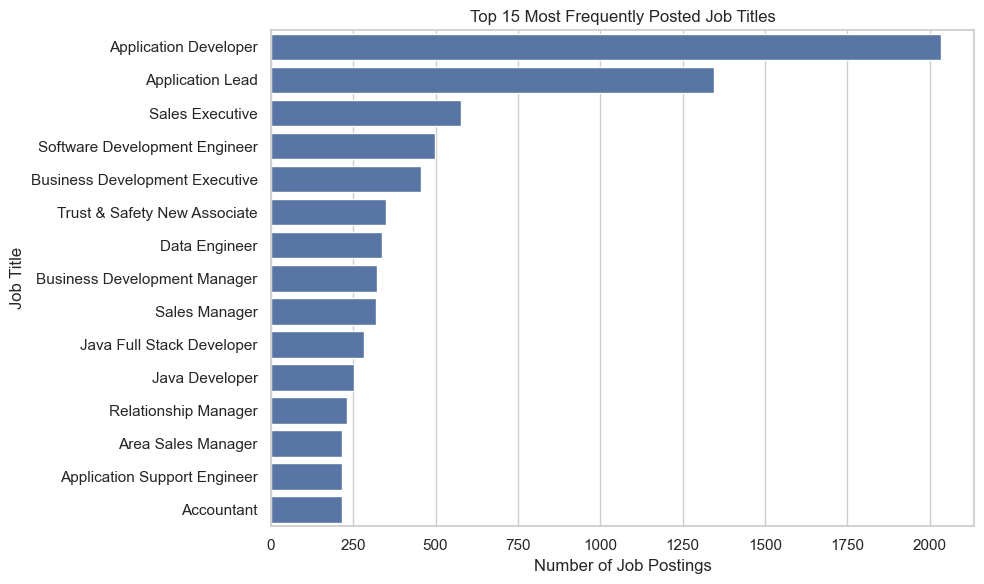

In [71]:
# ============================================
# EDA 1 — TOP JOB TITLES
# ============================================

top_titles = (
    df_analysis['title']
    .value_counts()
    .head(15)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_titles.values,
    y=top_titles.index
)

plt.title('Top 15 Most Frequently Posted Job Titles')
plt.xlabel('Number of Job Postings')
plt.ylabel('Job Title')

plt.tight_layout()
plt.show()

### Insight

Application Developer is the most frequently posted job title in the dataset, followed by Application Lead. Sales, software development, business development, and data-related roles also appear prominently among the top job titles.

This indicates that the dataset has strong representation from application development, sales, and technology-related roles. However, these results represent job-posting frequency in this dataset and should not be interpreted as the complete demand for these occupations across India.

# Top 15 Companies by Job Postings

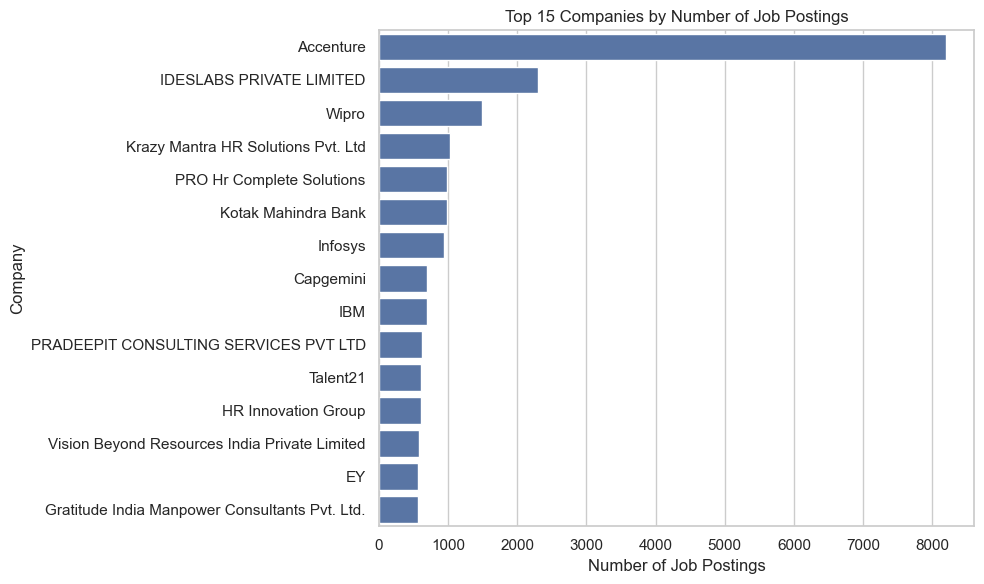

In [72]:
# ============================================
# EDA 2 — TOP COMPANIES
# ============================================

top_companies = (
    df_analysis['companyName']
    .value_counts()
    .head(15)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_companies.values,
    y=top_companies.index
)

plt.title('Top 15 Companies by Number of Job Postings')
plt.xlabel('Number of Job Postings')
plt.ylabel('Company')

plt.tight_layout()
plt.show()

### Insight

Accenture has the highest number of job postings in the dataset by a substantial margin, followed by IDESLABS PRIVATE LIMITED and Wipro. Several recruitment and staffing companies also appear among the organizations with high posting volumes.

This suggests that job-posting activity is concentrated among a small number of organizations and recruitment firms. Posting volume should not be interpreted as the number of employees hired or the total number of vacancies within a company.

# Top Locations

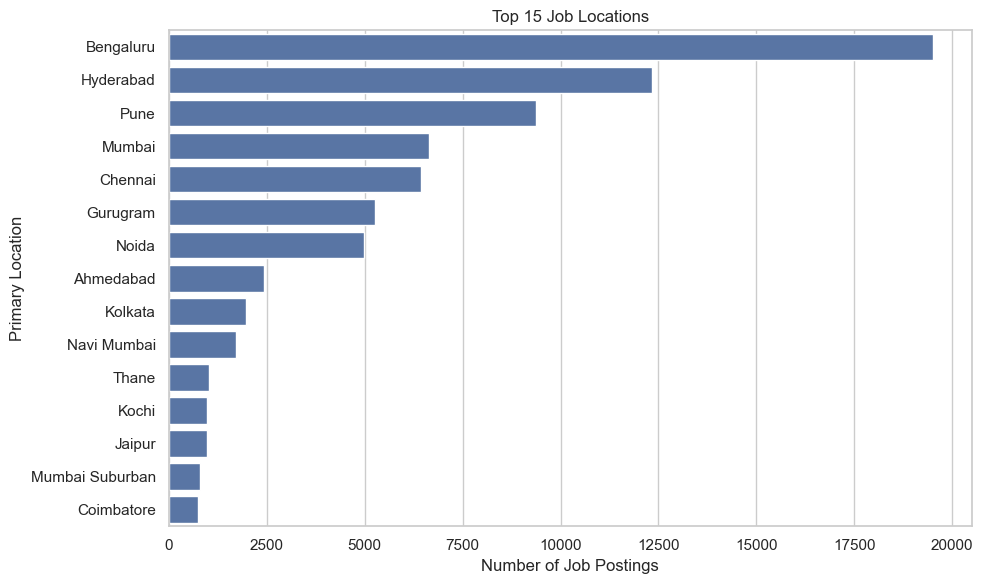

In [73]:
# ============================================
# EDA 3 — TOP JOB LOCATIONS
# ============================================

top_locations = (
    df_analysis[
        df_analysis['primary_location'] != 'Remote'
    ]['primary_location']
    .value_counts()
    .head(15)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_locations.values,
    y=top_locations.index
)

plt.title('Top 15 Job Locations')
plt.xlabel('Number of Job Postings')
plt.ylabel('Primary Location')

plt.tight_layout()
plt.show()

### Insight

Bengaluru has the highest number of job postings among the primary locations in the dataset, followed by Hyderabad and Pune. Mumbai, Chennai, Gurugram, and Noida also show substantial job-posting activity.

The concentration of postings in these major employment hubs indicates that technology and corporate job opportunities in the dataset are heavily concentrated in a limited number of major Indian cities.

# Work Mode

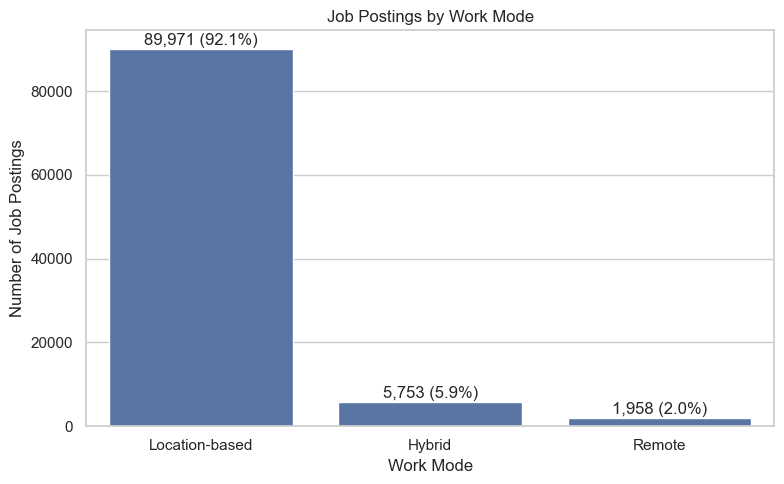

In [74]:
# ============================================
# EDA 4 — WORK MODE
# ============================================

work_mode_counts = (
    df_analysis['work_mode']
    .value_counts()
)

work_mode_pct = (
    work_mode_counts / work_mode_counts.sum() * 100
)

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=work_mode_counts.index,
    y=work_mode_counts.values
)

plt.title('Job Postings by Work Mode')
plt.xlabel('Work Mode')
plt.ylabel('Number of Job Postings')

for i, (count, pct) in enumerate(
    zip(work_mode_counts.values, work_mode_pct.values)
):
    ax.text(
        i,
        count + 1000,
        f'{count:,} ({pct:.1f}%)',
        ha='center'
    )

plt.tight_layout()
plt.show()

### Insight

Location-based jobs dominate the dataset, accounting for 92.1% of all postings. Hybrid opportunities account for 5.9%, while explicitly remote postings account for 2.0%.

This indicates that fully location-based roles are substantially more common than remote or hybrid roles in this dataset. The relatively small share of remote postings suggests that remote work opportunities are less frequently represented in these job postings.

# Salary Disclosure

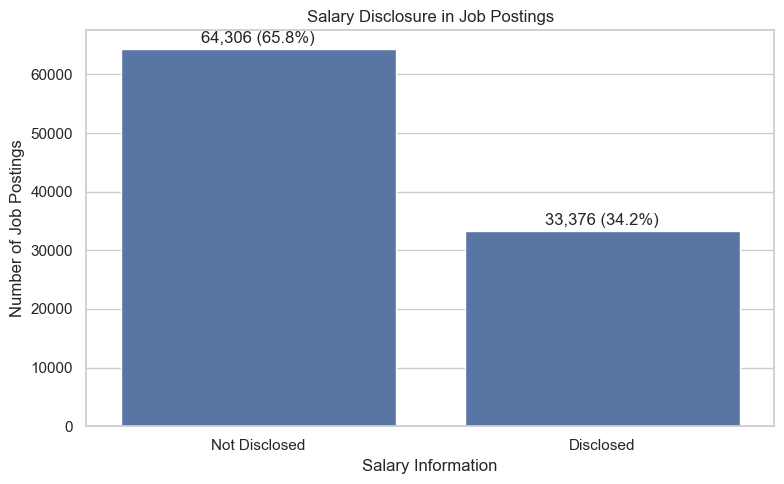

In [75]:
# ============================================
# EDA 5 — SALARY DISCLOSURE
# ============================================

salary_counts = (
    df_analysis['salary_disclosed']
    .map({True: 'Disclosed', False: 'Not Disclosed'})
    .value_counts()
)

salary_pct = (
    salary_counts / salary_counts.sum() * 100
)

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=salary_counts.index,
    y=salary_counts.values
)

plt.title('Salary Disclosure in Job Postings')
plt.xlabel('Salary Information')
plt.ylabel('Number of Job Postings')

for i, (count, pct) in enumerate(
    zip(salary_counts.values, salary_pct.values)
):
    ax.text(
        i,
        count + 1000,
        f'{count:,} ({pct:.1f}%)',
        ha='center'
    )

plt.tight_layout()
plt.show()

### Insight

Salary information is not disclosed in the majority of job postings. The salary analysis therefore focuses on postings with valid annual salary information.

During cleaning, salary values explicitly stated as monthly amounts were converted to annual salary equivalents. Records marked as **Unpaid** or **Not disclosed** remain missing because assigning ₹0 would distort salary statistics.

Because salary disclosure is incomplete, salary comparisons should be interpreted as comparisons among postings with usable salary information rather than the entire job market.


# Salary analysis dataframe

In [76]:
# ============================================
# SALARY ANALYSIS DATA
# ============================================

salary_df = df_analysis[
    df_analysis['salary_disclosed'] == True
].copy()

# All salary values are represented on an annual basis.
salary_df['salary_lakh'] = salary_df['salary_mid'] / 100000

print("Salary-disclosed postings:", len(salary_df))
print("Median annual salary: ₹", salary_df['salary_mid'].median())
print("Mean annual salary: ₹", round(salary_df['salary_mid'].mean(), 2))
print("Maximum annual salary: ₹", salary_df['salary_mid'].max())


Salary-disclosed postings: 33376
Median annual salary: ₹ 420000.0
Mean annual salary: ₹ 752947.68
Maximum annual salary: ₹ 82500000.0


# Salary Distribution

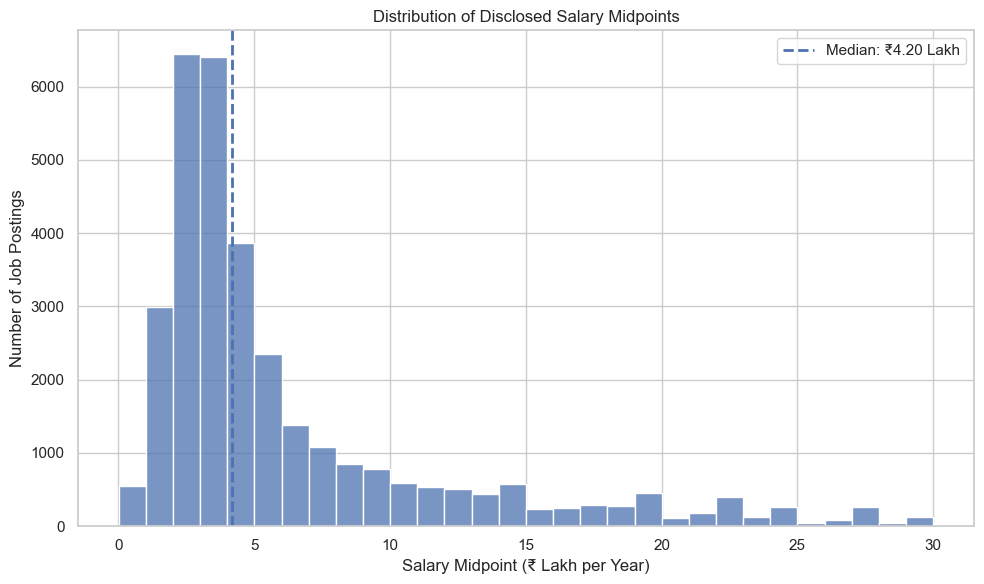

Postings above ₹30 lakh: 919 (2.75%)


In [77]:
# ============================================
# EDA 6 — SALARY DISTRIBUTION
# ============================================

salary_main = salary_df[
    salary_df['salary_lakh'] <= 30
]

excluded_high = (
    salary_df['salary_lakh'] > 30
).sum()

plt.figure(figsize=(10, 6))

sns.histplot(
    salary_main['salary_lakh'],
    bins=30
)

plt.axvline(
    salary_df['salary_lakh'].median(),
    linestyle='--',
    linewidth=2,
    label=f"Median: ₹{salary_df['salary_lakh'].median():.2f} Lakh"
)

plt.title('Distribution of Disclosed Salary Midpoints')
plt.xlabel('Salary Midpoint (₹ Lakh per Year)')
plt.ylabel('Number of Job Postings')

plt.legend()

plt.tight_layout()
plt.show()

print(
    f"Postings above ₹30 lakh: {excluded_high:,} "
    f"({excluded_high / len(salary_df) * 100:.2f}%)"
)

### Insight

The disclosed salary distribution is strongly right-skewed, with most salary midpoints concentrated between approximately ₹2 lakh and ₹5 lakh per year. The median salary is ₹4.25 lakh, while the mean is substantially higher at approximately ₹7.57 lakh because of the long upper tail.

Only 919 postings (2.77% of salary-disclosed jobs) have salary midpoints above ₹30 lakh, but these high-value postings have a noticeable effect on the overall mean. Therefore, the median is a more representative measure of the typical disclosed salary in this dataset.

# SALARY BOXPLOT

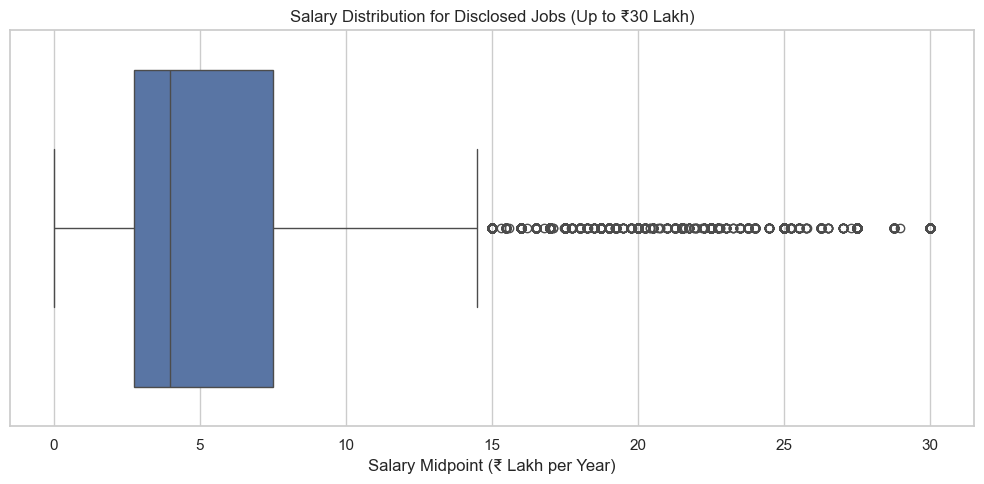

In [78]:
# ============================================
# EDA 7 — SALARY BOXPLOT (MAIN DISTRIBUTION)
# ============================================

salary_box = salary_df[
    salary_df['salary_lakh'] <= 30
]

plt.figure(figsize=(10, 5))

sns.boxplot(
    x=salary_box['salary_lakh']
)

plt.title('Salary Distribution for Disclosed Jobs (Up to ₹30 Lakh)')
plt.xlabel('Salary Midpoint (₹ Lakh per Year)')

plt.tight_layout()
plt.show()

### Insight

The boxplot shows that the middle 50% of disclosed salaries is concentrated within a relatively narrow range, while numerous higher-salary postings appear as outliers. This confirms the strong right-skew observed in the salary histogram.

The extreme salary observations should not automatically be treated as errors because they represent genuine high-value salary ranges in the dataset. Therefore, they are retained for analysis rather than removed as statistical outliers.

# Salary vs Experience

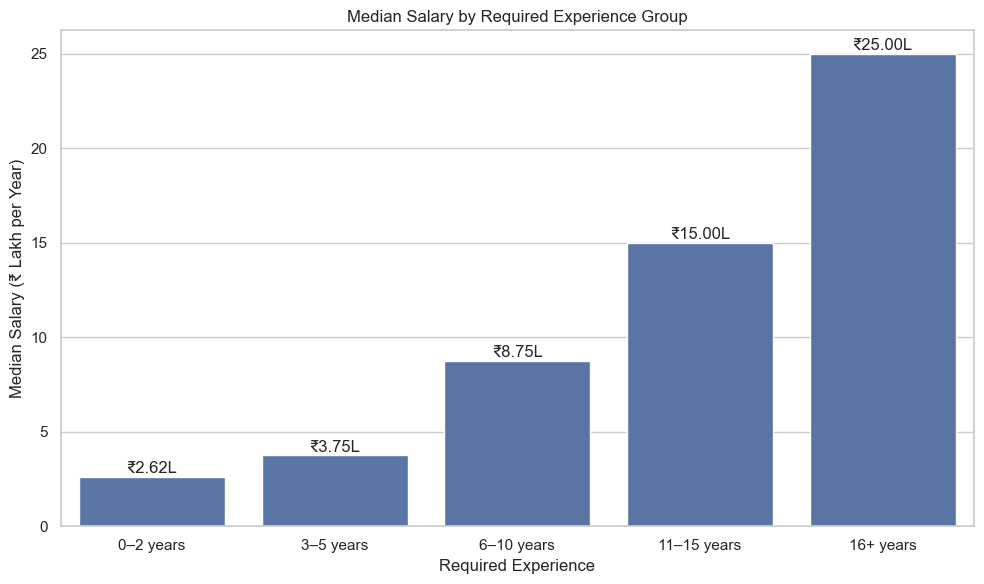

In [79]:
# ============================================
# EDA 8 — SALARY BY EXPERIENCE GROUP
# ============================================

experience_order = [
    '0–2 years',
    '3–5 years',
    '6–10 years',
    '11–15 years',
    '16+ years'
]

salary_experience = (
    salary_df
    .groupby('experience_group', observed=True)['salary_mid']
    .median()
    .reindex(experience_order)
    .dropna()
    / 100000
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=salary_experience.index,
    y=salary_experience.values
)

plt.title('Median Salary by Required Experience Group')
plt.xlabel('Required Experience')
plt.ylabel('Median Salary (₹ Lakh per Year)')

for i, value in enumerate(salary_experience.values):
    ax.text(
        i,
        value + 0.2,
        f'₹{value:.2f}L',
        ha='center'
    )

plt.tight_layout()
plt.show()

### Insight

Median disclosed salary increases substantially across every experience group. Jobs requiring 0–2 years of experience have a median salary of ₹2.62 lakh, compared with ₹25 lakh for jobs requiring 16+ years of experience.

The increase becomes particularly pronounced after 5 years of experience, with median salary rising from ₹3.75 lakh for the 3–5 year group to ₹8.75 lakh for the 6–10 year group. This indicates a strong positive association between required experience and disclosed salary in this dataset.

These results show an association rather than a causal relationship, since salary can also be influenced by factors such as job role, location, industry, company, and skills.

# Job Postings by Experience Group

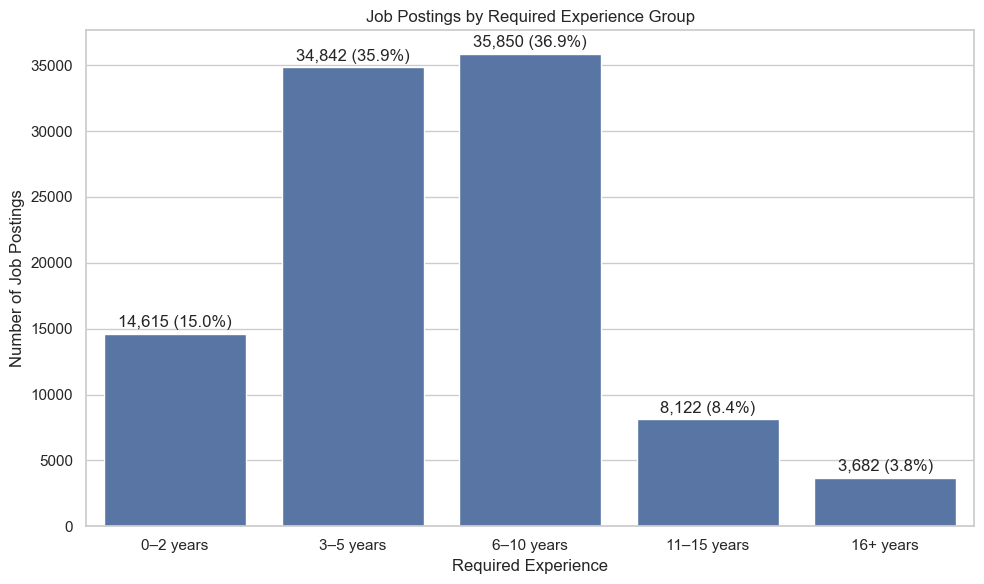

In [80]:
# ============================================
# EDA 9 — EXPERIENCE GROUP DISTRIBUTION
# ============================================

experience_counts = (
    df_analysis['experience_group']
    .value_counts()
    .reindex([
        '0–2 years',
        '3–5 years',
        '6–10 years',
        '11–15 years',
        '16+ years'
    ])
)

experience_pct = (
    experience_counts / experience_counts.sum() * 100
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=experience_counts.index,
    y=experience_counts.values
)

plt.title('Job Postings by Required Experience Group')
plt.xlabel('Required Experience')
plt.ylabel('Number of Job Postings')

for i, (count, pct) in enumerate(
    zip(experience_counts.values, experience_pct.values)
):
    ax.text(
        i,
        count + 500,
        f'{count:,} ({pct:.1f}%)',
        ha='center'
    )

plt.tight_layout()
plt.show()

### Insight

Job postings are heavily concentrated in the 3–10 year experience range. The 6–10 year group represents the largest share at 36.9%, followed closely by the 3–5 year group at 35.9%.

Together, these two groups account for approximately 72.8% of postings with available experience information. In contrast, only 3.8% of postings require 16+ years of experience, indicating that senior and highly experienced roles make up a relatively small share of the dataset.

# Median Salary by Location

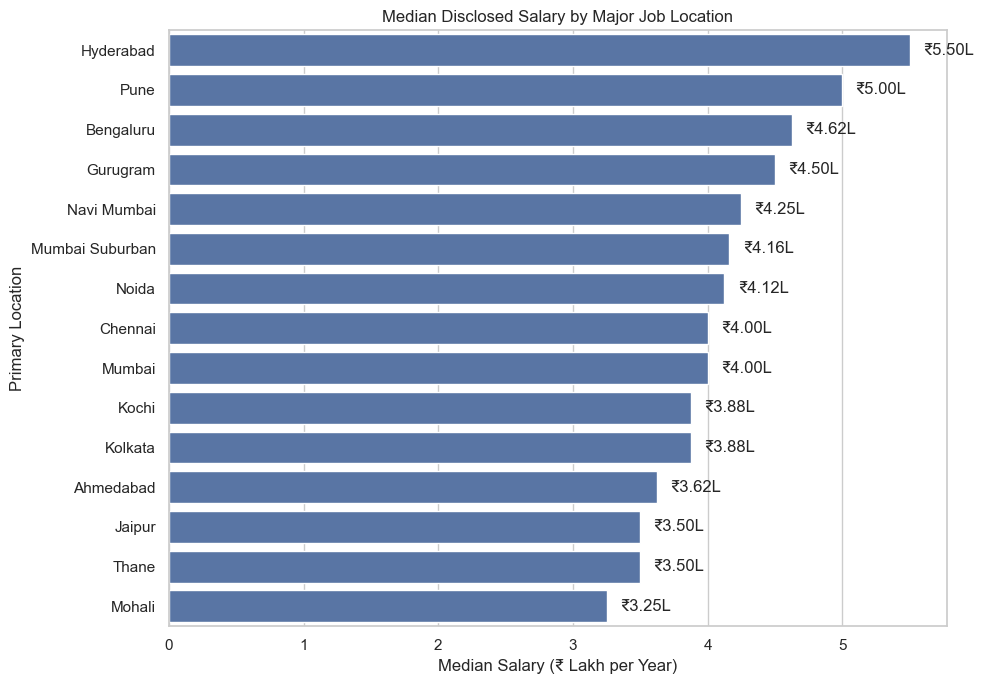

In [81]:
# ============================================
# EDA 10 — MEDIAN SALARY BY LOCATION
# ============================================

# Find locations with the most salary-disclosed postings
location_salary_counts = (
    salary_df[
        salary_df['primary_location'] != 'Remote'
    ]['primary_location']
    .value_counts()
)

top_salary_locations = location_salary_counts.head(15).index

# Calculate median salary for those locations
salary_by_location = (
    salary_df[
        salary_df['primary_location'].isin(top_salary_locations)
    ]
    .groupby('primary_location')['salary_mid']
    .median()
    .sort_values(ascending=False)
    / 100000
)

plt.figure(figsize=(10, 7))

ax = sns.barplot(
    x=salary_by_location.values,
    y=salary_by_location.index
)

plt.title('Median Disclosed Salary by Major Job Location')
plt.xlabel('Median Salary (₹ Lakh per Year)')
plt.ylabel('Primary Location')

for i, value in enumerate(salary_by_location.values):
    ax.text(
        value + 0.1,
        i,
        f'₹{value:.2f}L',
        va='center'
    )

plt.tight_layout()
plt.show()

### Insight

Among the major job locations with substantial salary-disclosed postings, Hyderabad has the highest median disclosed salary at ₹5.50 lakh per year, followed by Pune at ₹5.00 lakh and Bengaluru at ₹4.75 lakh.

Bengaluru has the largest overall number of job postings in the dataset, but it does not have the highest median disclosed salary. This shows that job-posting volume and typical disclosed salary can differ considerably across locations.

These differences represent an association in this dataset and may also reflect differences in job roles, experience requirements, industries, and company composition across locations.

# Salary by Work Mode

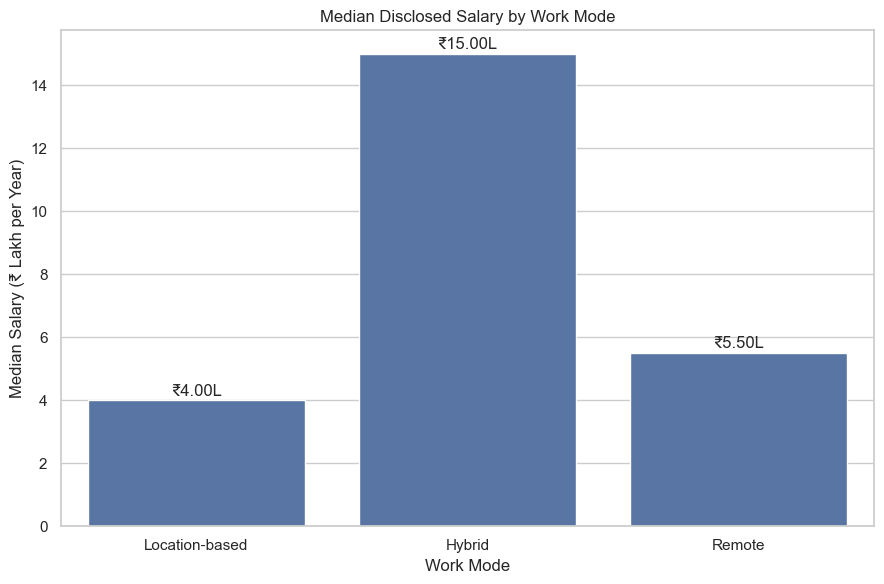

In [82]:
# ============================================
# EDA 11 — MEDIAN SALARY BY WORK MODE
# ============================================

work_mode_order = [
    'Location-based',
    'Hybrid',
    'Remote'
]

salary_by_work_mode = (
    salary_df
    .groupby('work_mode', observed=True)['salary_mid']
    .median()
    .reindex(work_mode_order)
    .dropna()
    / 100000
)

plt.figure(figsize=(9, 6))

ax = sns.barplot(
    x=salary_by_work_mode.index,
    y=salary_by_work_mode.values
)

plt.title('Median Disclosed Salary by Work Mode')
plt.xlabel('Work Mode')
plt.ylabel('Median Salary (₹ Lakh per Year)')

for i, value in enumerate(salary_by_work_mode.values):
    ax.text(
        i,
        value + 0.15,
        f'₹{value:.2f}L',
        ha='center'
    )

plt.tight_layout()
plt.show()

### Insight

Among salary-disclosed postings, hybrid jobs have the highest median salary at ₹15.00 lakh per year, followed by remote jobs at ₹6.00 lakh and location-based jobs at ₹4.00 lakh.

The difference is substantial even though the hybrid category contains 1,927 salary-disclosed postings. This indicates a strong association between work mode and disclosed salary in this dataset.

However, the result should not be interpreted as evidence that hybrid work itself causes higher salaries. The work-mode groups may differ substantially in terms of experience requirements, job roles, industries, and companies.

# Top Skills

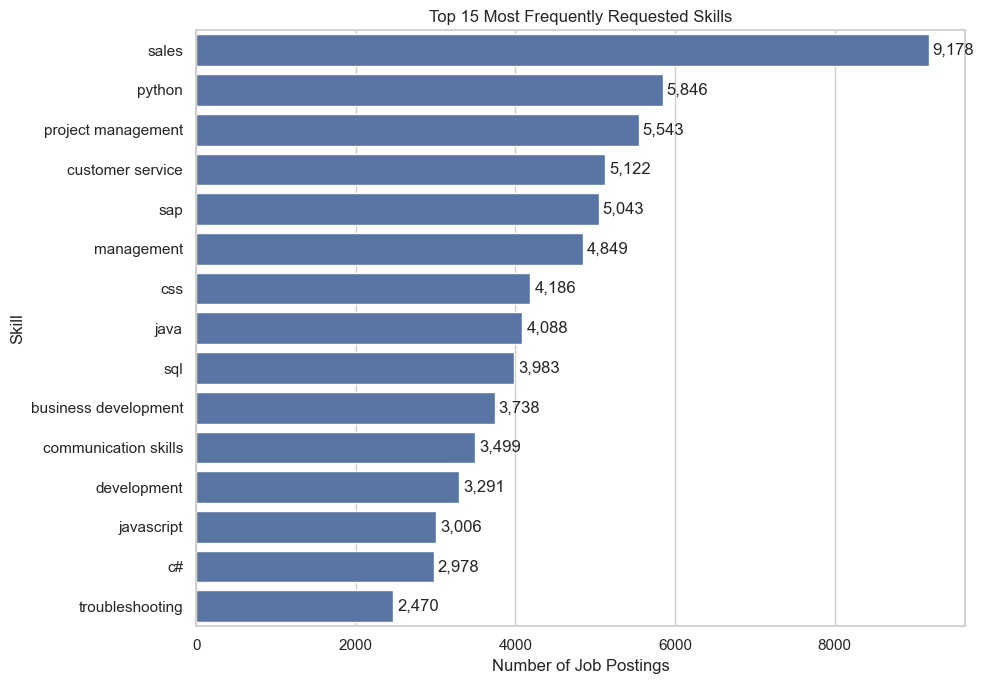

In [83]:
# ============================================
# EDA 12 — TOP SKILLS
# ============================================

from collections import Counter

skill_counter = Counter()

for skills in df_analysis['skills_clean']:
    if isinstance(skills, list):
        skill_counter.update(skills)

top_skills = pd.Series(skill_counter).sort_values(
    ascending=False
).head(15)

plt.figure(figsize=(10, 7))

ax = sns.barplot(
    x=top_skills.values,
    y=top_skills.index
)

plt.title('Top 15 Most Frequently Requested Skills')
plt.xlabel('Number of Job Postings')
plt.ylabel('Skill')

for i, value in enumerate(top_skills.values):
    ax.text(
        value + 50,
        i,
        f'{value:,}',
        va='center'
    )

plt.tight_layout()
plt.show()

### Insight

Sales is the most frequently requested skill in the dataset, appearing in 9,178 job postings. It is followed by Python, project management, customer service, and SAP, each appearing in more than 5,000 postings.

The top skills include a combination of technical skills such as Python, Java, SQL, JavaScript, C#, and SAP, as well as business and interpersonal skills such as sales, project management, customer service, management, and communication skills.

This indicates that demand in the dataset spans both technical and non-technical capabilities rather than being concentrated in a single skill category.

> **Skill methodology:** Skill frequencies represent the number of job postings containing each cleaned skill. A single job posting can contribute to multiple skill counts.

# Skills Associated With Higher Salary

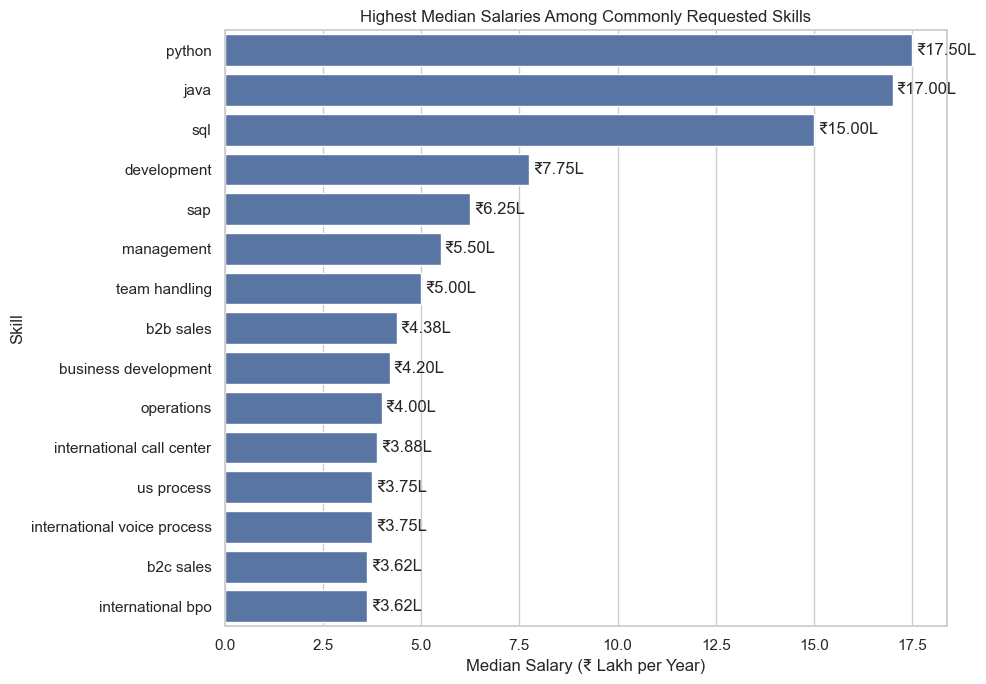

In [84]:
# ============================================
# EDA 13 — MEDIAN SALARY BY COMMON SKILL
# ============================================

from collections import defaultdict

skill_salary_data = defaultdict(list)

for _, row in salary_df.iterrows():
    skills = row['skills_clean']
    salary = row['salary_mid']
    
    if isinstance(skills, list) and pd.notna(salary):
        for skill in set(skills):
            skill_salary_data[skill].append(salary)

# Create summary
skill_salary_summary = pd.DataFrame([
    {
        'skill': skill,
        'job_count': len(salaries),
        'median_salary': pd.Series(salaries).median()
    }
    for skill, salaries in skill_salary_data.items()
])

# Keep only reasonably common skills
skill_salary_summary = skill_salary_summary[
    skill_salary_summary['job_count'] >= 500
].copy()

# Top 15 by median salary
top_salary_skills = (
    skill_salary_summary
    .sort_values('median_salary', ascending=False)
    .head(15)
)

top_salary_skills['median_salary_lakh'] = (
    top_salary_skills['median_salary'] / 100000
)

plt.figure(figsize=(10, 7))

ax = sns.barplot(
    data=top_salary_skills,
    x='median_salary_lakh',
    y='skill'
)

plt.title('Highest Median Salaries Among Commonly Requested Skills')
plt.xlabel('Median Salary (₹ Lakh per Year)')
plt.ylabel('Skill')

for i, value in enumerate(
    top_salary_skills['median_salary_lakh']
):
    ax.text(
        value + 0.1,
        i,
        f'₹{value:.2f}L',
        va='center'
    )

plt.tight_layout()
plt.show()

### Insight

Among commonly requested skills with at least 500 salary-disclosed postings, Python has the highest median disclosed salary at ₹17.50 lakh per year, followed by Java at ₹17.00 lakh and SQL at ₹15.00 lakh.

Technical skills such as Python, Java, and SQL show substantially higher median disclosed salaries than several business and operational skills in this comparison. However, these differences should not be interpreted as the direct effect of possessing a particular skill, because salary is also influenced by experience, job role, industry, company, and location.

The results therefore indicate an association between the presence of a skill in a job posting and the salary level of that posting.

> **Skill-salary methodology:** Only skills appearing in at least 500 salary-disclosed job postings were included to reduce the influence of very small samples. Salary values represent the median salary midpoint of postings containing each skill.

# Company Rating Distribution

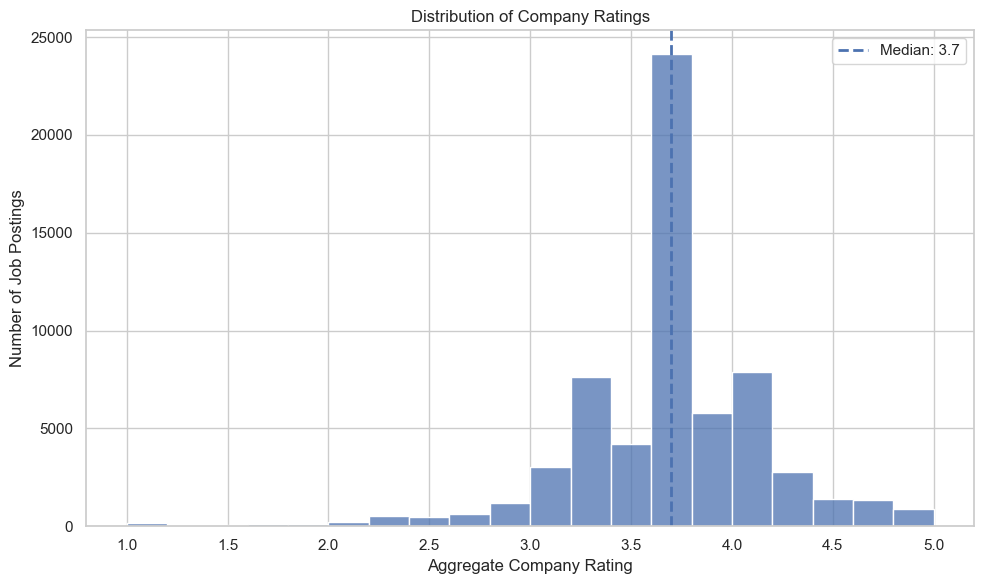

Jobs with ratings: 62517
Median rating: 3.7
Mean rating: 3.68


In [85]:
# ============================================
# EDA 14 — COMPANY RATING DISTRIBUTION
# ============================================

rating_df = df_analysis[
    df_analysis['AggregateRating'].notna()
].copy()

plt.figure(figsize=(10, 6))

sns.histplot(
    rating_df['AggregateRating'],
    bins=20
)

plt.axvline(
    rating_df['AggregateRating'].median(),
    linestyle='--',
    linewidth=2,
    label=f"Median: {rating_df['AggregateRating'].median():.1f}"
)

plt.title('Distribution of Company Ratings')
plt.xlabel('Aggregate Company Rating')
plt.ylabel('Number of Job Postings')

plt.legend()

plt.tight_layout()
plt.show()

print("Jobs with ratings:", len(rating_df))
print("Median rating:", rating_df['AggregateRating'].median())
print("Mean rating:", round(rating_df['AggregateRating'].mean(), 2))

### Insight

Company ratings are concentrated around the 3.5–4.0 range, with a median rating of 3.7 and a mean rating of 3.68 across 62,517 job postings with available ratings.

Very low ratings are relatively uncommon, while ratings above 4.0 are also less frequent than ratings around the dataset's central range. Overall, the distribution suggests that most companies represented in the dataset have moderate-to-good ratings.

# Salary by Company Rating

              count    median  median_lakh
rating_group                              
Below 3.0      1982  420000.0        4.200
3.0–3.49       3222  425000.0        4.250
3.5–3.99       5568  412500.0        4.125
4.0–4.49       1839  425000.0        4.250
4.5–5.0        1019  312500.0        3.125


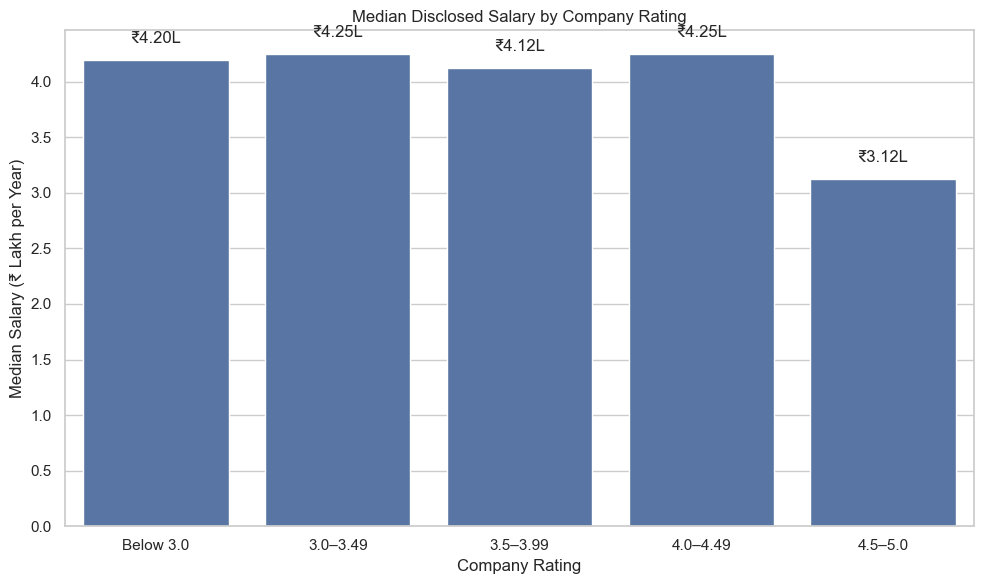

In [86]:
# ============================================
# EDA 15 — SALARY BY COMPANY RATING
# ============================================

rating_salary_df = salary_df[
    salary_df['AggregateRating'].notna()
].copy()

# Create rating groups
rating_salary_df['rating_group'] = pd.cut(
    rating_salary_df['AggregateRating'],
    bins=[0, 3, 3.5, 4, 4.5, 5],
    labels=[
        'Below 3.0',
        '3.0–3.49',
        '3.5–3.99',
        '4.0–4.49',
        '4.5–5.0'
    ],
    include_lowest=True
)

# Calculate median salary and number of postings
rating_salary_summary = (
    rating_salary_df
    .groupby('rating_group', observed=True)['salary_mid']
    .agg(['count', 'median'])
)

rating_salary_summary['median_lakh'] = (
    rating_salary_summary['median'] / 100000
)

print(rating_salary_summary)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=rating_salary_summary.index,
    y=rating_salary_summary['median_lakh']
)

plt.title('Median Disclosed Salary by Company Rating')
plt.xlabel('Company Rating')
plt.ylabel('Median Salary (₹ Lakh per Year)')

for i, value in enumerate(
    rating_salary_summary['median_lakh']
):
    ax.text(
        i,
        value + 0.15,
        f'₹{value:.2f}L',
        ha='center'
    )

plt.tight_layout()
plt.show()

### Insight

Company rating does not show a clear positive relationship with disclosed salary in this dataset. The median salary remains relatively similar across most rating groups, ranging from approximately ₹4.17 lakh to ₹4.38 lakh, while the highest-rated companies (4.5–5.0) have a lower median salary of ₹3.13 lakh.

This suggests that company rating alone is not a strong indicator of salary level in these job postings. Salary is likely influenced more strongly by factors such as experience, job role, skills, location, and industry.

Therefore, higher company ratings should not be interpreted as an indication of higher-paying jobs based on this dataset.

# Final Key Findings

### 1. Job Market Concentration
Job postings are highly concentrated in major Indian technology and business hubs. Bengaluru has the highest number of postings, followed by Hyderabad and Pune.

### 2. Work Mode
Location-based jobs dominate the dataset, accounting for 92.1% of all postings. Hybrid and remote opportunities represent much smaller shares of the observed job market.

### 3. Salary Transparency
Salary information is disclosed in only 33.9% of job postings, while 66.1% do not provide salary information. Therefore, salary-related findings are based only on postings with disclosed salary information.

### 4. Salary Distribution
Disclosed salaries are strongly right-skewed. Most postings are concentrated in the lower salary ranges, while a relatively small number of high-paying postings extend the distribution substantially.

### 5. Experience and Salary
Median disclosed salary increases substantially with required experience. Jobs requiring 16+ years of experience have the highest median salary, while 0–2 years have the lowest.

### 6. Skills in Demand
Sales is the most frequently requested skill, followed by Python, project management, customer service and SAP. Both technical and business-oriented skills appear prominently in the job market.

### 7. Skills and Salary
Among commonly requested skills with sufficient salary-disclosed postings, Python, Java and SQL have some of the highest median disclosed salaries.

### 8. Location and Salary
Median disclosed salaries vary across major job locations. Hyderabad and Pune show higher median salaries in this dataset, while several other major cities have lower medians.

### 9. Company Ratings
Company ratings are concentrated around 3.5–4.0, with a median rating of 3.7. Company rating does not show a clear positive relationship with disclosed salary in this dataset.

### 10. Important Limitation
These findings describe associations within the job postings dataset. They should not be interpreted as evidence that a particular skill, location, work mode or company rating directly causes higher salaries.

# Business Recommendations

### For Job Seekers
- Focus on high-demand technical skills such as Python, Java and SQL, which show strong salary outcomes among commonly requested skills.
- Consider gaining experience beyond entry-level roles, as disclosed salaries increase substantially with required experience.
- Major employment hubs such as Bengaluru, Hyderabad and Pune offer a large number of opportunities, while salary levels vary across locations.

### For Recruiters and Employers
- Clearly disclosing salary ranges can improve transparency and help attract relevant candidates.
- Employers should evaluate compensation against experience requirements and market location.
- The strong demand for both technical and business skills suggests that many roles require a combination of technical and communication/management capabilities.

### For Workforce Planning
- Job opportunities are heavily concentrated in major cities, particularly Bengaluru, Hyderabad and Pune.
- Location-based roles dominate the dataset, while hybrid and remote postings represent a smaller share.
- The demand for skills such as Python, SQL, Java, SAP and project management indicates diverse requirements across technical and business functions.

### For Data-Driven Hiring Decisions
- Salary should not be evaluated using company rating alone, as the analysis does not show a clear positive relationship between rating and disclosed salary.
- Hiring decisions should consider multiple factors including experience, skills, location, work mode and role requirements rather than relying on a single variable.

# Limitations

- Salary information is unavailable for approximately 66.1% of job postings, so salary analysis represents only the disclosed-salary subset.
- Job postings may contain inconsistencies in job titles, company names, locations and skill descriptions despite data cleaning.
- Multiple postings may represent similar roles or hiring requirements from the same company.
- Salary values represent advertised salary ranges and may not reflect the final compensation received by employees.
- The dataset represents job postings rather than actual employment outcomes.
- Relationships identified in the analysis are associations and should not be interpreted as causal relationships.
- Remote and hybrid salary comparisons should be interpreted cautiously because their sample sizes are much smaller than location-based postings.

# Conclusion

This exploratory data analysis examined 97,682 job postings to understand the Indian job market across job demand, salary, experience, location, work mode, skills and company ratings.

The analysis shows that job opportunities are concentrated in major employment hubs, particularly Bengaluru, Hyderabad and Pune, while location-based jobs dominate the dataset. Salary information is unavailable for a large majority of postings, making salary transparency an important limitation of the analysis.

Among postings with disclosed salaries, compensation increases substantially with required experience. Technical skills such as Python, Java and SQL are associated with relatively high median disclosed salaries, while Sales is the most frequently requested skill overall.

The analysis also shows that company ratings do not have a clear positive relationship with disclosed salary. Overall, the findings highlight the importance of considering multiple factors—including skills, experience, location, work mode and salary transparency—when evaluating the job market.

This analysis provides a data-driven overview of the observed job-posting market and can serve as a foundation for deeper analysis of career opportunities, compensation and hiring trends.